# Exploratory Data Analysis and Data Quality Assessment

## Notebook 02: CarDekho Used-Car Dataset

**Author:** Muhammad Waqas  
**Target Variable:** `Price`  
**Previous Notebook:** `01_data_understanding.ipynb`

## Objective

The objective of this notebook is to visually and statistically investigate
the distributions, relationships, unusual observations, and data-quality
issues in the CarDekho used-car dataset.

This analysis will examine:

- The distribution and skewness of Price
- Numerical feature distributions and outliers
- Categorical feature frequencies
- Relationships between vehicle characteristics and Price
- Suspicious mileage observations
- High-cardinality features
- Correlation and multicollinearity
- Possible transformations and feature-engineering requirements

## Research Focus

The analysis will help determine:

1. Which vehicle characteristics are associated with Price?
2. Whether the Price distribution requires logarithmic transformation
3. Whether extreme values are valid observations or likely data errors
4. Which features require cleaning, extraction, grouping, or removal
5. Which preprocessing decisions should be carried into the modeling pipeline

## Notebook Boundary

This notebook performs exploratory analysis only.

Final imputation, categorical encoding, feature scaling, train-test splitting,
and model training will be implemented in later notebooks through reproducible
pipelines to prevent data leakage.

## 1. Import Required Libraries and Load the Dataset



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

In [2]:
file_path = "../data/raw/car_price_data.csv"
df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)


Dataset loaded successfully.
Dataset shape: (2059, 20)


## 2. Statistical Profile of the Target Variable

The Price variable is examined before visualization to measure its range,
central tendency, variation, and skewness.

Target distribution is important because strong skewness and extreme values
can affect Linear Regression assumptions, residuals, and error metrics.

In [3]:
price_summary = df["Price"].describe().round(2)
price_skewness = df["Price"].skew()

print(price_summary)
print("\nPrice skewness:", round(price_skewness, 2))

count        2059.00
mean      1702991.70
std       2419880.64
min         49000.00
25%        484999.00
50%        825000.00
75%       1925000.00
max      35000000.00
Name: Price, dtype: float64

Price skewness: 4.97


### Target Statistical Observation

- Price has a strong positive skewness of 4.97.
- The mean Price is substantially higher than the median Price.
- Most vehicles are concentrated in the lower and middle price ranges.
- A relatively small number of luxury vehicles creates a long right tail.
- Original Price and log-transformed Price will both be evaluated during
  modeling rather than automatically removing expensive vehicles.

## 3. Distribution of Vehicle Prices

A histogram shows how vehicle prices are distributed across the dataset.
Prices are displayed in millions for easier interpretation.

The KDE curve provides a smooth estimate of the distribution shape.

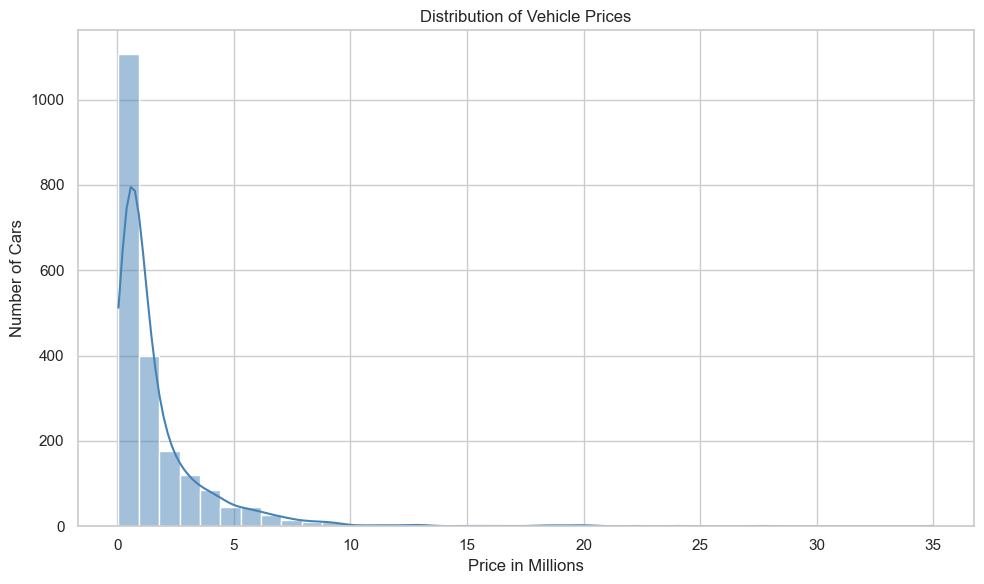

In [4]:
price_in_millions = df["Price"] / 1_000_000

plt.figure(figsize=(10, 6))

sns.histplot(
    price_in_millions,
    bins=40,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price in Millions")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Price-Distribution Observation

The histogram confirms that most vehicles are concentrated in the lower
price range, while a small number of luxury vehicles extends the distribution
to approximately 35 million.

The long right tail makes the original Price distribution highly skewed.
Because these expensive observations represent valid luxury vehicles, they
will be retained.

A logarithmic Price transformation will now be examined to reduce skewness
without deleting valid observations.

## 4. Log-Transformed Price Distribution

A logarithmic transformation compresses large values more strongly than
small values. It can reduce target skewness while retaining all valid
vehicle records.

The transformation is used only as an experiment. Original and log-target
models will later be compared on the original Price scale.

Original Price skewness: 4.97
Log Price skewness: 0.49


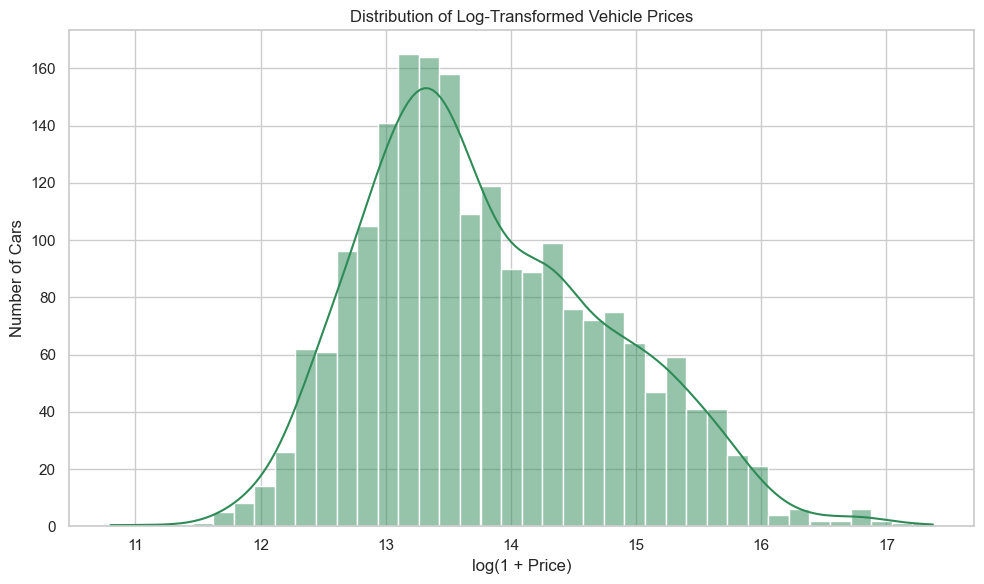

In [5]:
log_price = np.log1p(df["Price"])

print("Original Price skewness:", round(df["Price"].skew(), 2))
print("Log Price skewness:", round(log_price.skew(), 2))

plt.figure(figsize=(10, 6))

sns.histplot(
    log_price,
    bins=40,
    kde=True,
    color="seagreen"
)

plt.title("Distribution of Log-Transformed Vehicle Prices")
plt.xlabel("log(1 + Price)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/log_price_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Transformation Finding

- Log transformation reduced Price skewness from 4.97 to 0.49.
- The transformed distribution is substantially more balanced and closer
  to symmetry.
- The extreme luxury-vehicle prices remain in the dataset but have less
  influence on the transformed scale.
- The distribution still shows some structure and is not perfectly normal.
- Both original-target and log-target models will be trained and compared.
- Predictions from the log-target model will be converted back to the
  original Price scale before final evaluation.

## 5. Distribution of Manufacturing Year

The Year distribution is examined to understand the age coverage of vehicles
and whether the dataset is dominated by recent or older cars.

Vehicle year is expected to have an important relationship with Price.

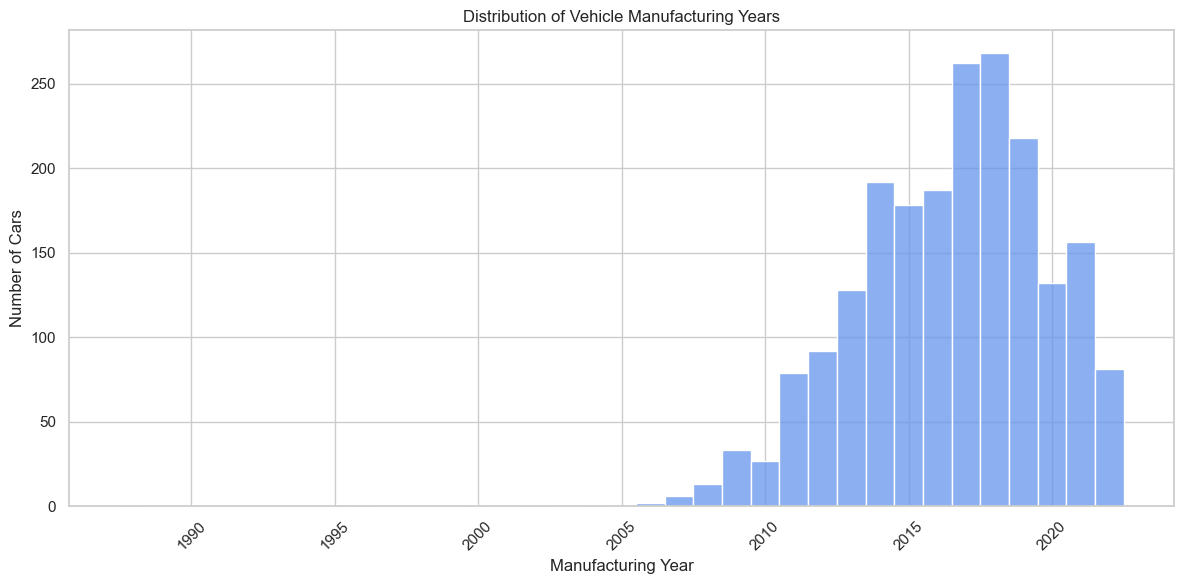

In [6]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=df,
    x="Year",
    discrete=True,
    color="cornflowerblue"
)

plt.title("Distribution of Vehicle Manufacturing Years")
plt.xlabel("Manufacturing Year")
plt.ylabel("Number of Cars")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "../results/figures/year_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Manufacturing-Year Observation

- Most vehicles were manufactured between approximately 2012 and 2021.
- The largest concentration occurs around 2017 and 2018.
- Vehicles manufactured before 2010 are underrepresented.
- The model may therefore generalize better to recent vehicles than to
  substantially older vehicles.
- Vehicle age is likely to be more interpretable than the raw manufacturing
  year for explaining depreciation.

### 5.1 Vehicle-Age Proxy

The dataset does not contain an explicit listing date. Therefore, the maximum
manufacturing year in the dataset is used as a reference year to create an
approximate vehicle-age feature.

This is an exploratory proxy and not a confirmed age at the time of sale.

In [7]:
reference_year = df["Year"].max()

df["Vehicle Age"] = reference_year - df["Year"]

print("Reference year:", reference_year)
print("Minimum vehicle age:", df["Vehicle Age"].min())
print("Maximum vehicle age:", df["Vehicle Age"].max())

Reference year: 2022
Minimum vehicle age: 0
Maximum vehicle age: 34


## 6. Statistical Profile of Kilometer

The Kilometer variable is examined using percentiles and skewness because
its maximum value is much larger than the typical observations.

Percentiles help distinguish the normal data range from a small number of
extreme values.

In [8]:
kilometer_summary = df["Kilometer"].describe(
    percentiles=[0.90, 0.95, 0.99]
).round(2)

kilometer_skewness = df["Kilometer"].skew()

print(kilometer_summary)
print("\nKilometer skewness:", round(kilometer_skewness, 2))

count       2059.00
mean       54224.71
std        57361.72
min            0.00
50%        50000.00
90%        90000.00
95%       107991.10
99%       147100.00
max      2000000.00
Name: Kilometer, dtype: float64

Kilometer skewness: 20.98


### Kilometer Statistical Observation

- The median recorded mileage is 50,000 km.
- Ninety-nine percent of vehicles have Kilometer values at or below 147,100.
- The maximum value of 2,000,000 is substantially larger than the 99th
  percentile.
- Kilometer skewness is extremely high at 20.98.
- A very small number of observations strongly affects the mean, standard
  deviation, and visual distribution.
- These values require sensitivity analysis before a final treatment decision.

### 6.1 Full and Zoomed Kilometer Distributions

The first plot includes all records. The second plot displays observations
up to the 99th percentile to reveal the main distribution.

The zoomed plot is for visualization only. No records are deleted.

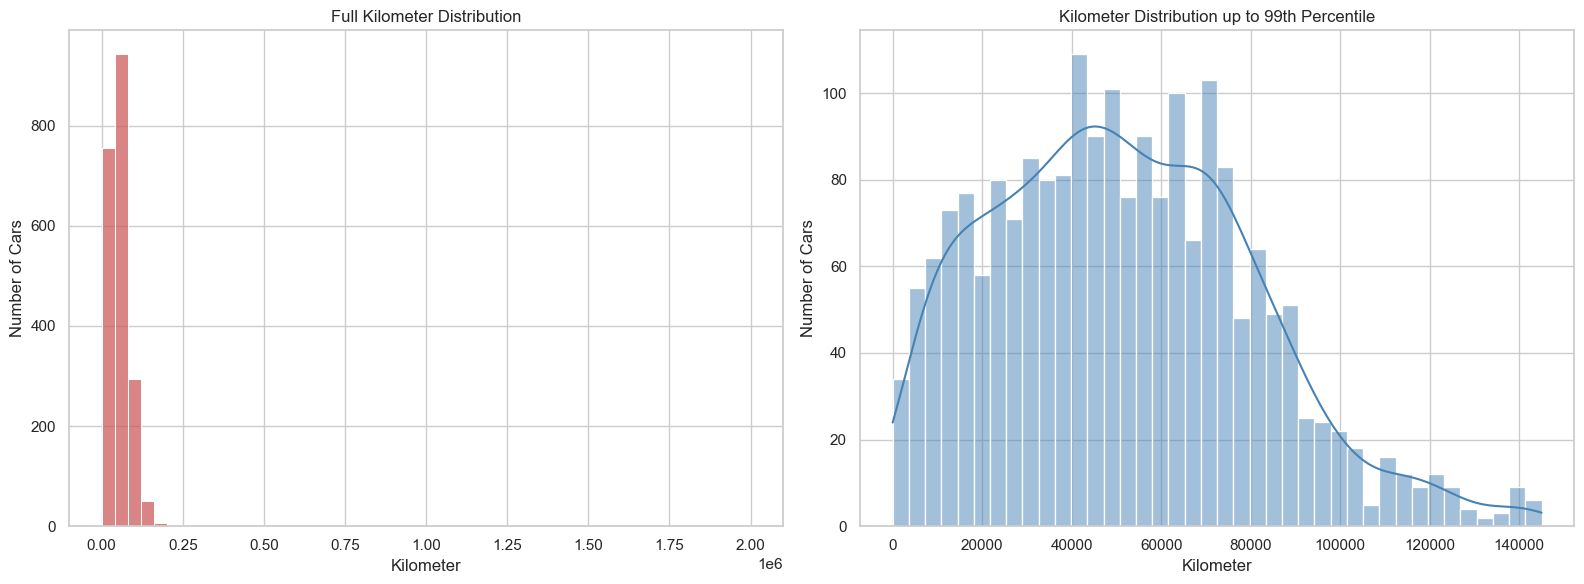

In [9]:
kilometer_99 = df["Kilometer"].quantile(0.99)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.histplot(
    data=df,
    x="Kilometer",
    bins=50,
    ax=axes[0],
    color="indianred"
)

axes[0].set_title("Full Kilometer Distribution")
axes[0].set_xlabel("Kilometer")
axes[0].set_ylabel("Number of Cars")

sns.histplot(
    data=df[df["Kilometer"] <= kilometer_99],
    x="Kilometer",
    bins=40,
    kde=True,
    ax=axes[1],
    color="steelblue"
)

axes[1].set_title("Kilometer Distribution up to 99th Percentile")
axes[1].set_xlabel("Kilometer")
axes[1].set_ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/kilometer_full_and_zoomed.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kilometer-Distribution Finding

The complete histogram is dominated by a very small number of extreme
mileage observations. After zooming to the 99th percentile, the main
distribution becomes visible.

Most vehicles fall below approximately 100,000 km, with the highest
concentration around 40,000 to 70,000 km. The main distribution remains
right-skewed but is substantially more plausible than the complete view.

Potential treatments will include log transformation and sensitivity
analysis. Extreme records will not be silently deleted or corrected.

### 6.2 Log-Transformed Kilometer Distribution

A log transformation is evaluated to reduce the influence of large mileage
values. Because Kilometer contains zero values, `log1p()` is used.

Log transformation can reduce skewness, but it does not prove that suspicious
records are valid.

Original Kilometer skewness: 20.98
Log Kilometer skewness: -3.03


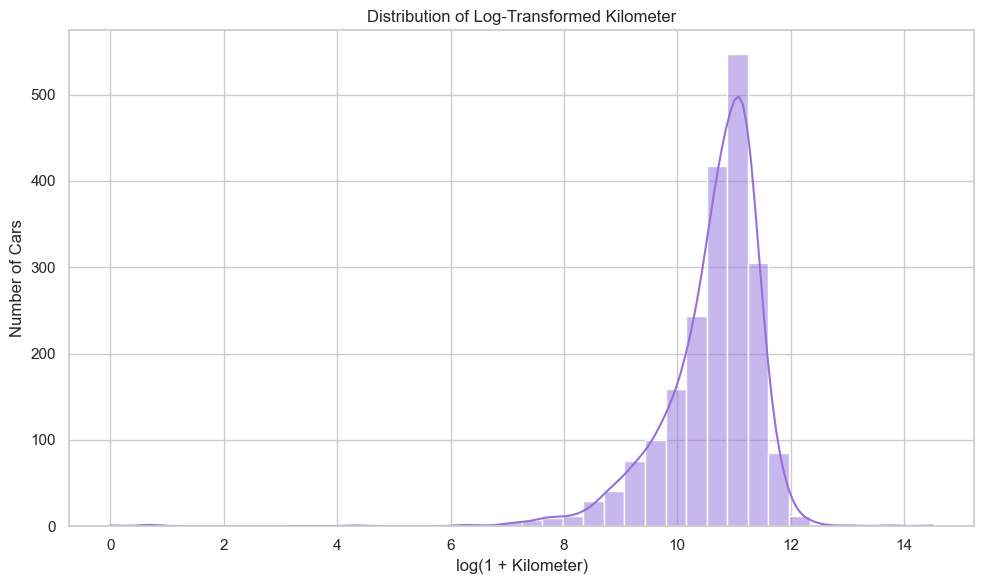

In [10]:
log_kilometer = np.log1p(df["Kilometer"])

print(
    "Original Kilometer skewness:",
    round(df["Kilometer"].skew(), 2)
)

print(
    "Log Kilometer skewness:",
    round(log_kilometer.skew(), 2)
)

plt.figure(figsize=(10, 6))

sns.histplot(
    log_kilometer,
    bins=40,
    kde=True,
    color="mediumpurple"
)

plt.title("Distribution of Log-Transformed Kilometer")
plt.xlabel("log(1 + Kilometer)")
plt.ylabel("Number of Cars")

plt.tight_layout()

plt.savefig(
    "../results/figures/log_kilometer_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Log-Kilometer Finding

Log transformation compressed the extremely high Kilometer values but changed
the distribution from strong positive skewness to strong negative skewness.

The transformed skewness of -3.03 indicates that log transformation does not
provide a balanced Kilometer distribution. Zero and very-low mileage records
form a long left tail after transformation.

Therefore, log-transformed Kilometer will not automatically replace the raw
feature. Zero values and suspiciously low mileage records must first be
investigated.

### 6.3 Investigation of Zero and Low Kilometer Values

Zero and very-low mileage records are examined because they strongly affect
the log-transformed distribution.

These records may represent new, unregistered, demonstration, or incorrectly
recorded vehicles.

In [11]:
print(
    "Kilometer equal to 0:",
    (df["Kilometer"] == 0).sum()
)

print(
    "Kilometer from 1 to 100:",
    df["Kilometer"].between(1, 100).sum()
)

print(
    "Kilometer from 101 to 1000:",
    df["Kilometer"].between(101, 1000).sum()
)

low_kilometer_columns = [
    "Make",
    "Model",
    "Price",
    "Year",
    "Kilometer",
    "Owner"
]

df.sort_values(
    by="Kilometer"
)[low_kilometer_columns].head(15)

Kilometer equal to 0: 1
Kilometer from 1 to 100: 3
Kilometer from 101 to 1000: 3


,Make,Model,Price,Year,Kilometer,Owner
1766,MINI,Cooper JCW Hatchback,5200000,2022,0,UnRegistered Car
1746,Audi,A4 Premium Plus 40 TFSI,4151000,2022,1,UnRegistered Car
139,Audi,Q5 45 TFSI Premium Plus,5651000,2022,1,UnRegistered Car
2044,Mahindra,XUV700 AX 7 Petrol AT Luxury Pack 7 STR,2765000,2022,75,First
1563,Mercedes-Benz,C-Class C220d Progressive,6100000,2022,500,First
387,MG,Astor Sharp EX 1.5 MT,1550000,2022,600,First
1506,Honda,Amaze 1.2 VX MT Petrol [2018-2020],700000,2022,1000,First
1533,Mercedes-Benz,E-Class 200,7050000,2022,1102,UnRegistered Car
741,Hyundai,Creta SX 1.4 Turbo 7 DCT,1911000,2022,1300,First
1208,Skoda,Kushaq Style 1.0L TSI MT,1600000,2022,1300,First


### Low-Kilometer Finding

Only seven vehicles have recorded mileage between 0 and 1,000 km.

The zero- and one-kilometer records are 2022 vehicles marked as unregistered,
while the remaining low-mileage records are also recent vehicles. These values
are contextually plausible and will be retained.

The strong negative skewness after log transformation is partly caused by a
small number of valid new or nearly new vehicles rather than clear data errors.

Raw, transformed, and outlier-treated Kilometer strategies will therefore be
compared through cross-validation.

## 7. Relationship Between Vehicle Age and Price

Vehicle age is expected to have a negative relationship with Price because
vehicles generally depreciate over time.

Log-transformed Price is used for visualization because the original Price
scale is strongly affected by luxury vehicles.

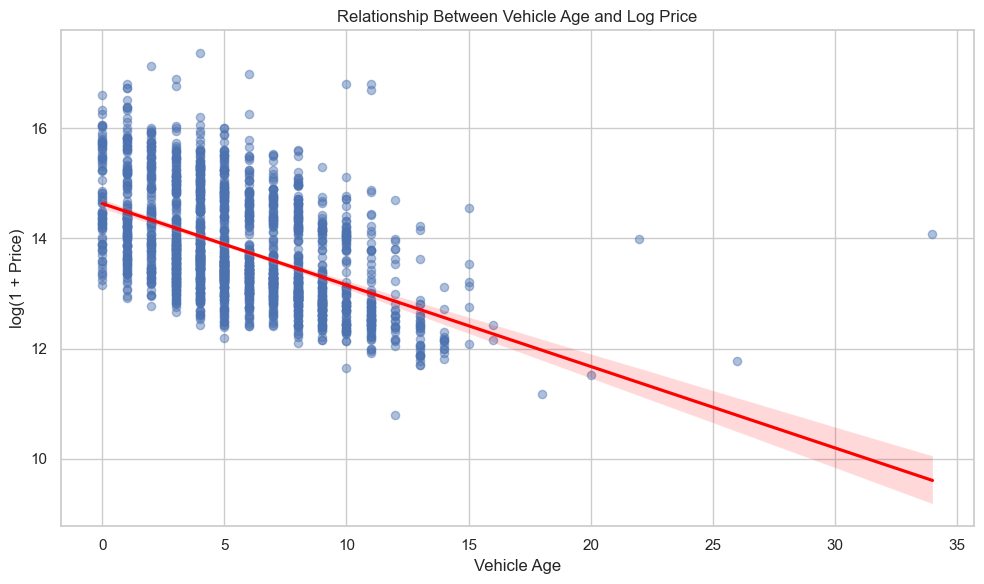

In [12]:
df["Log Price"] = np.log1p(df["Price"])

plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x="Vehicle Age",
    y="Log Price",
    scatter_kws={
        "alpha": 0.45,
        "s": 35
    },
    line_kws={
        "color": "red"
    }
)

plt.title("Relationship Between Vehicle Age and Log Price")
plt.xlabel("Vehicle Age")
plt.ylabel("log(1 + Price)")

plt.tight_layout()

plt.savefig(
    "../results/figures/vehicle_age_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Vehicle-Age Relationship Finding

Vehicle Age has a clear negative association with Log Price. Newer vehicles
generally have higher prices, while older vehicles tend to have lower prices.

The wide vertical spread at each age shows that depreciation is not the only
determinant of Price. Brand, model, technical specifications, location, and
other characteristics are also important.

The uncertainty band becomes wider for older vehicles because relatively few
old vehicles are available in the dataset. Some older vehicles also retain
unusually high prices and require contextual investigation.

### 7.1 Vehicle-Age Correlation with Price

Pearson correlation measures linear association, while Spearman correlation
measures monotonic rank-based association.

Both are calculated because raw Price contains extreme luxury values.

In [13]:
age_price_pearson = df["Vehicle Age"].corr(
    df["Price"],
    method="pearson"
)

age_log_price_pearson = df["Vehicle Age"].corr(
    df["Log Price"],
    method="pearson"
)

age_price_spearman = df["Vehicle Age"].corr(
    df["Price"],
    method="spearman"
)

print(
    "Pearson correlation: Vehicle Age vs Price:",
    round(age_price_pearson, 3)
)

print(
    "Pearson correlation: Vehicle Age vs Log Price:",
    round(age_log_price_pearson, 3)
)

print(
    "Spearman correlation: Vehicle Age vs Price:",
    round(age_price_spearman, 3)
)

Pearson correlation: Vehicle Age vs Price: -0.311
Pearson correlation: Vehicle Age vs Log Price: -0.507
Spearman correlation: Vehicle Age vs Price: -0.52


### Vehicle-Age Correlation Finding

Vehicle Age has a moderate negative relationship with vehicle Price.

The Pearson correlation becomes stronger after applying the logarithmic Price
transformation, changing from -0.311 to -0.507. The Spearman correlation of
-0.520 provides similar evidence of a monotonic depreciation pattern.

This supports evaluating Log Price as a modeling target because it produces
a more linear relationship with Vehicle Age.

## 8. Relationship Between Kilometer and Price

Mileage is expected to have a negative association with vehicle Price.
However, a small number of extreme Kilometer values may distort the apparent
linear relationship.

The complete data and the main 99-percent range are visualized separately.

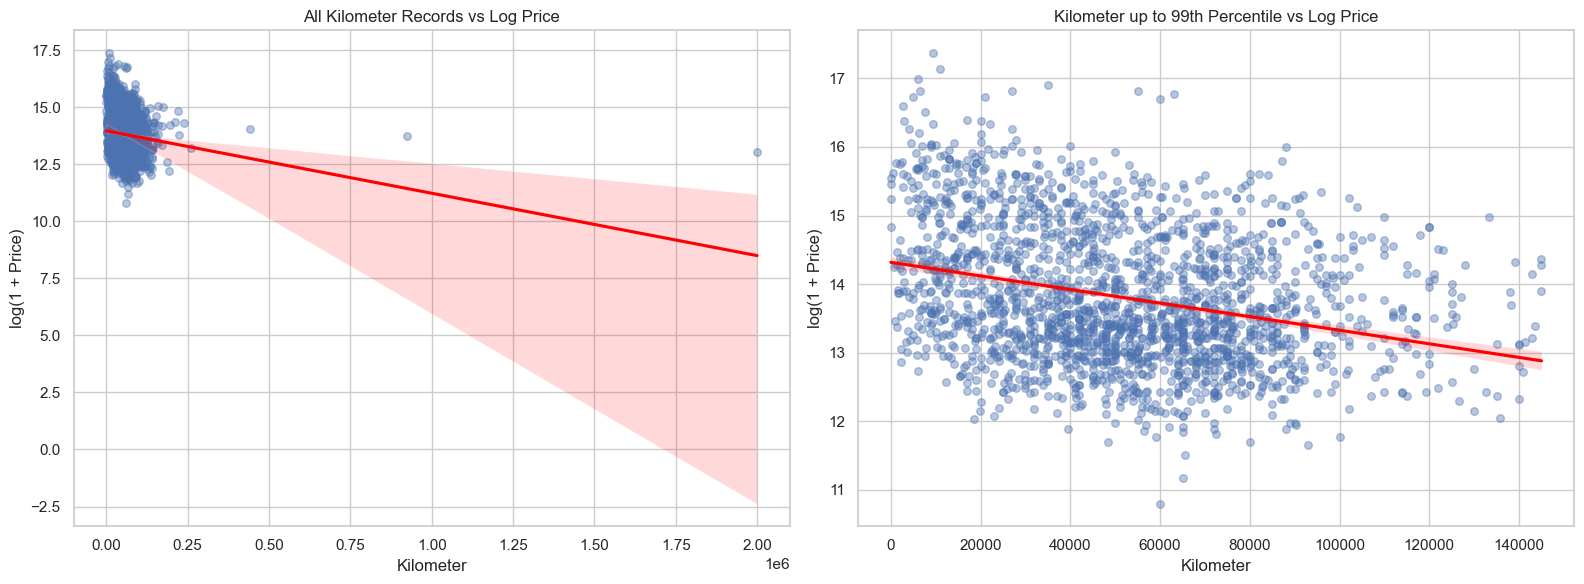

In [14]:
main_kilometer_data = df[
    df["Kilometer"] <= kilometer_99
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.regplot(
    data=df,
    x="Kilometer",
    y="Log Price",
    scatter_kws={
        "alpha": 0.40,
        "s": 30
    },
    line_kws={
        "color": "red"
    },
    ax=axes[0]
)

axes[0].set_title("All Kilometer Records vs Log Price")
axes[0].set_xlabel("Kilometer")
axes[0].set_ylabel("log(1 + Price)")

sns.regplot(
    data=main_kilometer_data,
    x="Kilometer",
    y="Log Price",
    scatter_kws={
        "alpha": 0.40,
        "s": 30
    },
    line_kws={
        "color": "red"
    },
    ax=axes[1]
)

axes[1].set_title("Kilometer up to 99th Percentile vs Log Price")
axes[1].set_xlabel("Kilometer")
axes[1].set_ylabel("log(1 + Price)")

plt.tight_layout()

plt.savefig(
    "../results/figures/kilometer_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Kilometer–Price Relationship Finding

The full-data regression line is strongly affected by a very small number
of extreme Kilometer observations. These records produce a wide uncertainty
band and an unstable visual trend.

After restricting the visualization to the 99th percentile, a clearer
negative relationship appears: vehicles with higher mileage generally have
lower prices.

The substantial vertical spread indicates that mileage alone is insufficient
to explain Price. Brand, age, model, engine characteristics, and other
features must also be considered.

The extreme Kilometer records are potential high-leverage observations and
their influence will be evaluated through model diagnostics and sensitivity
experiments.

### 8.1 Kilometer Correlation with Price

Correlations are calculated for the complete data and for observations up to
the 99th Kilometer percentile to measure the effect of extreme mileage values.

In [15]:
kilometer_log_price_full = df["Kilometer"].corr(
    df["Log Price"],
    method="pearson"
)

kilometer_log_price_main = main_kilometer_data[
    "Kilometer"
].corr(
    main_kilometer_data["Log Price"],
    method="pearson"
)

kilometer_price_spearman = df["Kilometer"].corr(
    df["Price"],
    method="spearman"
)

print(
    "Pearson correlation, complete data:",
    round(kilometer_log_price_full, 3)
)

print(
    "Pearson correlation, up to 99th percentile:",
    round(kilometer_log_price_main, 3)
)

print(
    "Spearman correlation, complete data:",
    round(kilometer_price_spearman, 3)
)

Pearson correlation, complete data: -0.16
Pearson correlation, up to 99th percentile: -0.294
Spearman correlation, complete data: -0.279


### Kilometer Correlation Finding

Kilometer has a negative but relatively weak association with vehicle Price.

The complete-data Pearson correlation is -0.160. After restricting the
analysis to the 99th Kilometer percentile, the correlation becomes stronger
at -0.294. This confirms that a small number of extreme mileage records
weakens and distorts the linear relationship.

The Spearman correlation of -0.279 provides similar evidence of a weak
monotonic relationship. Mileage is therefore relevant but cannot explain
vehicle Price independently.

The 99th-percentile restriction was used only for sensitivity analysis.
The final treatment of extreme mileage observations will be implemented
inside the modeling workflow and evaluated through cross-validation.

## 9. Technical Feature Format Inspection

Engine, Max Power, and Max Torque contain numerical specifications combined
with units and text.

Before extracting numerical features, sample values are inspected to identify
different units, decimal formats, and RPM ranges.

In [16]:
technical_columns = [
    "Engine",
    "Max Power",
    "Max Torque"
]

for column in technical_columns:
    print("\n", column)
    print(
        df[column]
        .dropna()
        .sample(15, random_state=42)
        .to_string(index=False)
    )


 Engine
1196 cc
1197 cc
1197 cc
1998 cc
1199 cc
2179 cc
1950 cc
2179 cc
1498 cc
1248 cc
1248 cc
2993 cc
1373 cc
1493 cc
1199 cc

 Max Power
 73 bhp @ 6000 rpm
 79 bhp @ 6000 rpm
 82 bhp @ 6000 rpm
248 bhp @ 5200 rpm
 89 bhp @ 6000 rpm
120 bhp @ 4000 rpm
192 bhp @ 3800 rpm
120 bhp @ 4000 rpm
 99 bhp @ 3750 rpm
 89 bhp @ 4000 rpm
 89 bhp @ 4000 rpm
271 bhp @ 4000 rpm
 91 bhp @ 6000 rpm
113 bhp @ 4000 rpm
 74 bhp @ 4200 rpm

 Max Torque
101 Nm @ 3000 rpm
112 Nm @ 4000 rpm
113 Nm @ 4200 rpm
350 Nm @ 1450 rpm
110 Nm @ 4800 rpm
280 Nm @ 1800 rpm
400 Nm @ 1600 rpm
280 Nm @ 1800 rpm
205 Nm @ 1750 rpm
200 Nm @ 1750 rpm
200 Nm @ 1750 rpm
600 Nm @ 2000 rpm
130 Nm @ 4000 rpm
250 Nm @ 1500 rpm
180 Nm @ 2000 rpm


### Initial Technical-Format Observation

The inspected samples use consistent formats:

- Engine displacement is reported in cc.
- Maximum power is reported in bhp with an associated RPM.
- Maximum torque is reported in Nm with an associated RPM.

The complete dataset will now be checked for alternative units and RPM ranges
before numerical extraction.

In [17]:
engine_units = df["Engine"].str.extract(
    r"([A-Za-z]+)\s*$",
    expand=False
).value_counts(dropna=False)

power_units = df["Max Power"].str.extract(
    r"[\d.]+\s*([A-Za-z]+)\s*@",
    expand=False
).value_counts(dropna=False)

torque_units = df["Max Torque"].str.extract(
    r"[\d.]+\s*([A-Za-z]+)\s*@",
    expand=False
).value_counts(dropna=False)

power_rpm_ranges = df["Max Power"].str.contains(
    r"@\s*[\d,]+\s*[-–]\s*[\d,]+",
    regex=True,
    na=False
).sum()

torque_rpm_ranges = df["Max Torque"].str.contains(
    r"@\s*[\d,]+\s*[-–]\s*[\d,]+",
    regex=True,
    na=False
).sum()

print("Engine units:")
print(engine_units)

print("\nPower units:")
print(power_units)

print("\nTorque units:")
print(torque_units)

print("\nPower RPM ranges:", power_rpm_ranges)
print("Torque RPM ranges:", torque_rpm_ranges)

Engine units:
Engine
cc     1979
NaN      80
Name: count, dtype: int64

Power units:
Max Power
bhp    1851
NaN     208
Name: count, dtype: int64

Torque units:
Max Torque
Nm     1851
NaN     208
Name: count, dtype: int64

Power RPM ranges: 0
Torque RPM ranges: 0


### Complete Format-Audit Finding

All available Engine values use the cc unit.

For Max Power and Max Torque, 1,851 records follow the complete
value-unit-RPM format. Eighty records are missing, while 128 additional
non-missing records do not match the complete pattern.

No RPM ranges were detected. The unmatched records will be inspected before
feature extraction.

In [18]:
power_complete_pattern = df["Max Power"].str.contains(
    r"[\d.]+\s*bhp\s*@\s*[\d,]+\s*rpm",
    regex=True,
    case=False,
    na=False
)

torque_complete_pattern = df["Max Torque"].str.contains(
    r"[\d.]+\s*Nm\s*@\s*[\d,]+\s*rpm",
    regex=True,
    case=False,
    na=False
)

unmatched_power = df.loc[
    df["Max Power"].notna() & ~power_complete_pattern,
    "Max Power"
]

unmatched_torque = df.loc[
    df["Max Torque"].notna() & ~torque_complete_pattern,
    "Max Torque"
]

print("Unmatched Power examples:")
print(unmatched_power.value_counts().head(15))

print("\nUnmatched Torque examples:")
print(unmatched_torque.value_counts().head(15))

Unmatched Power examples:
Max Power
118@6600    14
75@4000     10
68@6200      8
80@5200      7
67@5500      6
47@6200      6
59@6200      5
132@6000     4
87@6000      4
102@5600     4
150@4000     3
171@3600     3
67@6200      3
90@4000      3
170@3700     3
Name: count, dtype: int64

Unmatched Torque examples:
Max Torque
146@4600    14
190@2000    10
90@3500      8
99@2800      6
62@3000      6
111@4000     6
77@3500      5
113@4500     4
84@3500      4
170@4200     4
220@1750     3
200@1400     3
410@2000     3
343@1400     3
540@1600     2
Name: count, dtype: int64


### Unmatched-Format Finding

The 128 unmatched records contain compact specifications such as `118@6600`
and `146@4600`.

These values contain both the technical measurement and RPM, but omit the
written units. Based on the column definitions and the consistent units used
by the remaining records, the first number is interpreted as BHP for Max Power
and Nm for Max Torque.

This documented assumption allows both full and compact formats to be parsed
without deleting valid records.

### 9.1 Numerical Technical Feature Extraction

Numerical values are extracted from the original text columns while preserving
the raw columns unchanged.

The extracted features are:

- Engine_CC
- Power_BHP
- Power_RPM
- Torque_NM
- Torque_RPM

In [19]:
df["Engine_CC"] = pd.to_numeric(
    df["Engine"].str.extract(
        r"([\d.]+)",
        expand=False
    ),
    errors="coerce"
)

df["Power_BHP"] = pd.to_numeric(
    df["Max Power"].str.extract(
        r"^\s*([\d.]+)",
        expand=False
    ),
    errors="coerce"
)

power_rpm_text = df["Max Power"].str.extract(
    r"@\s*([\d,]+)",
    expand=False
)

df["Power_RPM"] = pd.to_numeric(
    power_rpm_text.str.replace(
        ",",
        "",
        regex=False
    ),
    errors="coerce"
)

df["Torque_NM"] = pd.to_numeric(
    df["Max Torque"].str.extract(
        r"^\s*([\d.]+)",
        expand=False
    ),
    errors="coerce"
)

torque_rpm_text = df["Max Torque"].str.extract(
    r"@\s*([\d,]+)",
    expand=False
)

df["Torque_RPM"] = pd.to_numeric(
    torque_rpm_text.str.replace(
        ",",
        "",
        regex=False
    ),
    errors="coerce"
)

In [ ]:
technical_features = [
    "Engine_CC",
    "Power_BHP",
    "Power_RPM",
    "Torque_NM",
    "Torque_RPM"
]

print("Extracted feature non-null counts:")
print(df[technical_features].notna().sum())

print("\nExtracted feature missing counts:")
print(df[technical_features].isna().sum())

df[
    [
        "Engine",
        "Engine_CC",
        "Max Power",
        "Power_BHP",
        "Power_RPM",
        "Max Torque",
        "Torque_NM",
        "Torque_RPM"
    ]
].head(10)

### Extraction Completeness Finding

Engine_CC, Power_BHP, Torque_NM, and Torque_RPM retain 1,979 valid values,
matching the original non-missing technical records.

Power_RPM contains four additional missing values. These records have usable
power measurements but may not contain an RPM value or may use a different
format. They will be inspected separately.

In [21]:
missing_power_rpm_records = df.loc[
    df["Max Power"].notna() &
    df["Power_RPM"].isna(),
    [
        "Make",
        "Model",
        "Max Power",
        "Power_BHP",
        "Power_RPM"
    ]
]

missing_power_rpm_records

,Make,Model,Max Power,Power_BHP,Power_RPM
456,MINI,Countryman Cooper D,112 bhp @,112.0,NaN
747,MINI,Cooper S,189 bhp @,189.0,NaN
835,MINI,Cooper S,189 bhp @,189.0,NaN
2014,MINI,Countryman Cooper D,112 bhp @,112.0,NaN


### Missing Power-RPM Finding

Four MINI records contain a valid BHP value followed by an incomplete
`@` symbol without an RPM measurement.

The available Power_BHP values are retained. Power_RPM remains missing because
an undocumented value will not be guessed or manually inserted.

This is a source-data incompleteness issue rather than an extraction failure.

In [22]:
technical_summary = (
    df[technical_features]
    .describe()
    .round(2)
    .T
)

technical_summary

,count,mean,std,min,25%,50%,75%,max
Engine_CC,1979.0,1692.58,643.74,624.0,1197.0,1498.0,1995.0,6592.0
Power_BHP,1979.0,129.61,65.07,35.0,83.0,116.0,171.0,660.0
Power_RPM,1975.0,4835.09,1097.37,2910.0,4000.0,4200.0,6000.0,8250.0
Torque_NM,1979.0,245.85,140.47,48.0,115.0,200.0,350.0,780.0
Torque_RPM,1979.0,2619.55,1206.31,150.0,1600.0,1900.0,4000.0,6500.0


### Technical Summary Observation

The median vehicle has approximately a 1,498 cc engine, 116 BHP, and 200 Nm
of torque.

Maximum engine, power, and torque values are substantially higher and may
represent luxury or high-performance vehicles. These values require contextual
verification before being treated as outliers.

The minimum Torque_RPM value of 150 is unusually low and requires specific
record-level inspection.

In [23]:
technical_display_columns = [
    "Make",
    "Model",
    "Year",
    "Engine",
    "Max Power",
    "Max Torque",
    "Engine_CC",
    "Power_BHP",
    "Power_RPM",
    "Torque_NM",
    "Torque_RPM"
]

print("Largest Engine records:")
display(
    df.nlargest(
        5,
        "Engine_CC"
    )[technical_display_columns]
)

print("Largest Power records:")
display(
    df.nlargest(
        5,
        "Power_BHP"
    )[technical_display_columns]
)

print("Largest Torque records:")
display(
    df.nlargest(
        5,
        "Torque_NM"
    )[technical_display_columns]
)

print("Smallest Torque RPM records:")
display(
    df.nsmallest(
        10,
        "Torque_RPM"
    )[technical_display_columns]
)

Largest Engine records:


,Make,Model,Year,Engine,Max Power,Max Torque,Engine_CC,Power_BHP,Power_RPM,Torque_NM,Torque_RPM
977,Rolls-Royce,Ghost 6.5,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
575,Mercedes-Benz,S-Class 500L,2012,5461 cc,368 bhp @ 6300 rpm,505 Nm @ 4400 rpm,5461.0,368.0,6300.0,505.0,4400.0
510,Lamborghini,Huracan LP 610-4,2016,5204 cc,602 bhp @ 8250 rpm,560 Nm @ 6500 rpm,5204.0,602.0,8250.0,560.0,6500.0


Largest Power records:


,Make,Model,Year,Engine,Max Power,Max Torque,Engine_CC,Power_BHP,Power_RPM,Torque_NM,Torque_RPM
483,Ferrari,488 GTB,2018,3902 cc,660 bhp @ 8000 rpm,760 Nm @ 3000 rpm,3902.0,660.0,8000.0,760.0,3000.0
510,Lamborghini,Huracan LP 610-4,2016,5204 cc,602 bhp @ 8250 rpm,560 Nm @ 6500 rpm,5204.0,602.0,8250.0,560.0,6500.0
977,Rolls-Royce,Ghost 6.5,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0


Largest Torque records:


,Make,Model,Year,Engine,Max Power,Max Torque,Engine_CC,Power_BHP,Power_RPM,Torque_NM,Torque_RPM
977,Rolls-Royce,Ghost 6.5,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1246,Rolls-Royce,Ghost Extended Wheelbase,2011,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
1369,Rolls-Royce,Ghost Extended Wheelbase,2012,6592 cc,570 bhp @ 5250 rpm,780 Nm @ 1500 rpm,6592.0,570.0,5250.0,780.0,1500.0
483,Ferrari,488 GTB,2018,3902 cc,660 bhp @ 8000 rpm,760 Nm @ 3000 rpm,3902.0,660.0,8000.0,760.0,3000.0
160,Mercedes-Benz,S-Class Maybach S 500,2016,4663 cc,453 bhp @ 5250 rpm,700 Nm @ 1800 rpm,4663.0,453.0,5250.0,700.0,1800.0


Smallest Torque RPM records:


,Make,Model,Year,Engine,Max Power,Max Torque,Engine_CC,Power_BHP,Power_RPM,Torque_NM,Torque_RPM
721,Audi,A3 40 TFSI Premium Plus + sunroof,2018,1798 cc,178 bhp @ 5100 rpm,250 Nm @ 150 rpm,1798.0,178.0,5100.0,250.0,150.0
6,Mercedes-Benz,CLA 200 Petrol Sport,2015,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,1991.0,181.0,5500.0,300.0,1200.0
55,Toyota,Innova 2.5 GX BS IV 7 STR,2015,2494 cc,101 bhp @ 3600 rpm,200 Nm @ 1200 rpm,2494.0,101.0,3600.0,200.0,1200.0
169,Mercedes-Benz,C-Class C 200 Avantgarde,2015,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,1991.0,181.0,5500.0,300.0,1200.0
229,Toyota,Innova 2.8 GX AT 7 STR [2016-2020],2018,2755 cc,172 bhp @ 3400 rpm,360 Nm @ 1200 rpm,2755.0,172.0,3400.0,360.0,1200.0
313,Mercedes-Benz,C-Class C 200 Avantgarde,2016,1991 cc,181 bhp @ 5500 rpm,300 Nm @ 1200 rpm,1991.0,181.0,5500.0,300.0,1200.0
542,Mercedes-Benz,GLS 400d 4MATIC,2021,2925 cc,326 bhp @ 3600 rpm,700 Nm @ 1200 rpm,2925.0,326.0,3600.0,700.0,1200.0
675,Mercedes-Benz,E-Class E 200,2016,1991 cc,184 bhp @ 5500 rpm,300 Nm @ 1200 rpm,1991.0,184.0,5500.0,300.0,1200.0
682,Mercedes-Benz,C-Class C200 Progressive,2021,1991 cc,201 bhp @ 5800 rpm,300 Nm @ 1200 rpm,1991.0,201.0,5800.0,300.0,1200.0
701,Toyota,Innova 2.8 ZX AT 7 STR [2016-2020],2018,2755 cc,172 bhp @ 3400 rpm,360 Nm @ 1200 rpm,2755.0,172.0,3400.0,360.0,1200.0


### Technical-Extreme Investigation Finding

The maximum Engine_CC, Power_BHP, and Torque_NM values belong to recognized
luxury and high-performance vehicles. These observations are contextually
valid and will be retained.

The Audi A3 record containing `250 Nm @ 150 rpm` is inconsistent with the
remaining Torque_RPM range and may contain a missing zero. It will be compared
with similar vehicle records before defining a cleaning rule.

In [24]:
audi_a3_records = df.loc[
    df["Model"].str.contains(
        "A3 40 TFSI",
        case=False,
        na=False
    ),
    [
        "Make",
        "Model",
        "Year",
        "Max Power",
        "Max Torque",
        "Torque_RPM"
    ]
]

audi_a3_records

,Make,Model,Year,Max Power,Max Torque,Torque_RPM
721,Audi,A3 40 TFSI Premium Plus + sunroof,2018,178 bhp @ 5100 rpm,250 Nm @ 150 rpm,150.0
1361,Audi,A3 40 TFSI Premium,2017,178 bhp @ 5100 rpm,250 Nm @ 1250 rpm,1250.0


### Suspicious Torque-RPM Decision

A similar Audi A3 variant reports maximum torque at 1,250 RPM, while the
suspicious record reports 150 RPM.

This comparison supports treating 150 RPM as an invalid data entry. However,
the exact intended value cannot be confirmed. Therefore, the raw value will
remain unchanged, while the cleaned analytical feature will mark it as missing
rather than replacing it with a guessed value.

In [25]:
df["Torque_RPM_Clean"] = df["Torque_RPM"].copy()

invalid_torque_rpm = df["Torque_RPM_Clean"] < 500

print(
    "Torque RPM values below 500:",
    invalid_torque_rpm.sum()
)

df.loc[
    invalid_torque_rpm,
    "Torque_RPM_Clean"
] = np.nan

print(
    "Missing Torque_RPM_Clean values:",
    df["Torque_RPM_Clean"].isna().sum()
)

Torque RPM values below 500: 1
Missing Torque_RPM_Clean values: 81


## 10. Distributions of Extracted Technical Features

The extracted technical features are visualized to examine their shapes,
spread, skewness, and possible extreme values.

The cleaned Torque RPM feature is used for visualization.

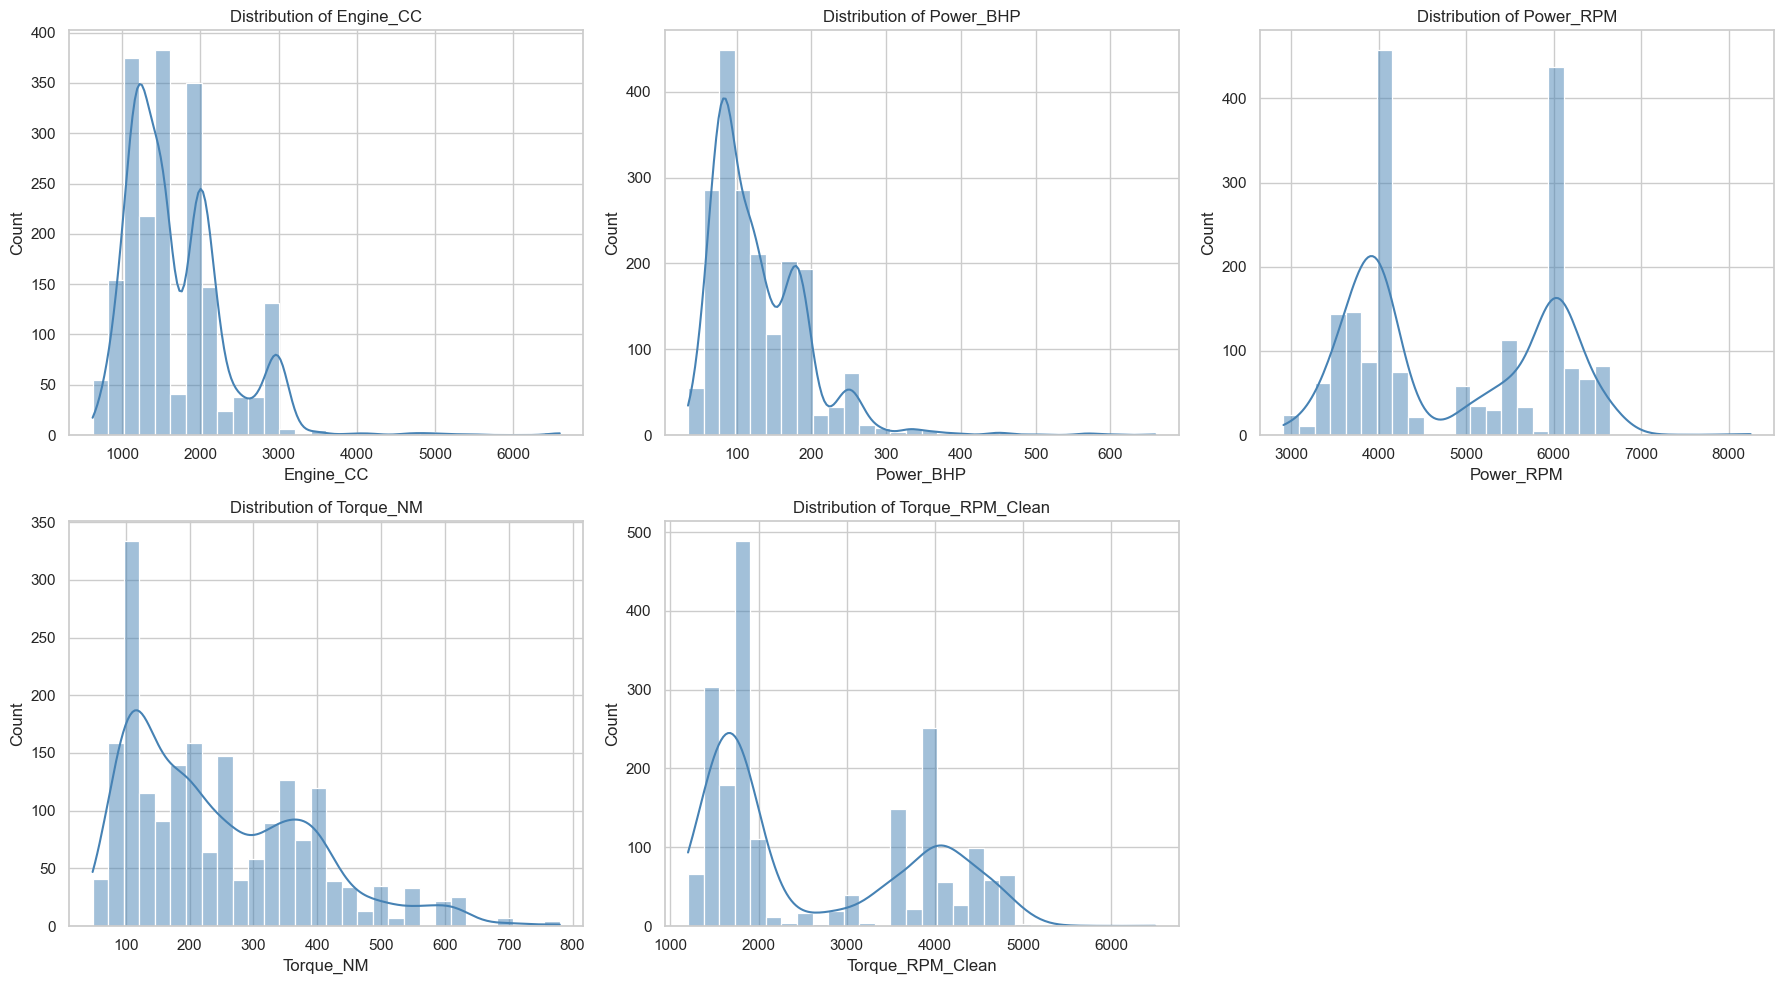

In [26]:
technical_plot_features = [
    "Engine_CC",
    "Power_BHP",
    "Power_RPM",
    "Torque_NM",
    "Torque_RPM_Clean"
]

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for index, column in enumerate(technical_plot_features):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[index],
        color="steelblue"
    )

    axes[index].set_title(
        f"Distribution of {column}"
    )

axes[5].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/figures/technical_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Technical-Distribution Finding

The technical features show multimodal rather than uniform distributions.

Engine displacement, power, and torque contain distinct vehicle segments and
right tails associated with high-performance vehicles. Power RPM and Torque
RPM also contain clear operating-speed clusters.

These patterns are contextually plausible and support the real-world nature
of the dataset. Predictor normality is not required for Linear Regression,
so transformations will be considered only if they improve relationships,
residual behavior, or cross-validated performance.

## 11. Technical Features and Vehicle Price

Scatter plots and Pearson correlations are used to evaluate how engine,
power, torque, and RPM specifications relate to Log Price.

Technical correlations with Log Price:
Power_BHP           0.823
Torque_NM           0.815
Engine_CC           0.704
Power_RPM          -0.407
Torque_RPM_Clean   -0.504
Name: Log Price, dtype: float64


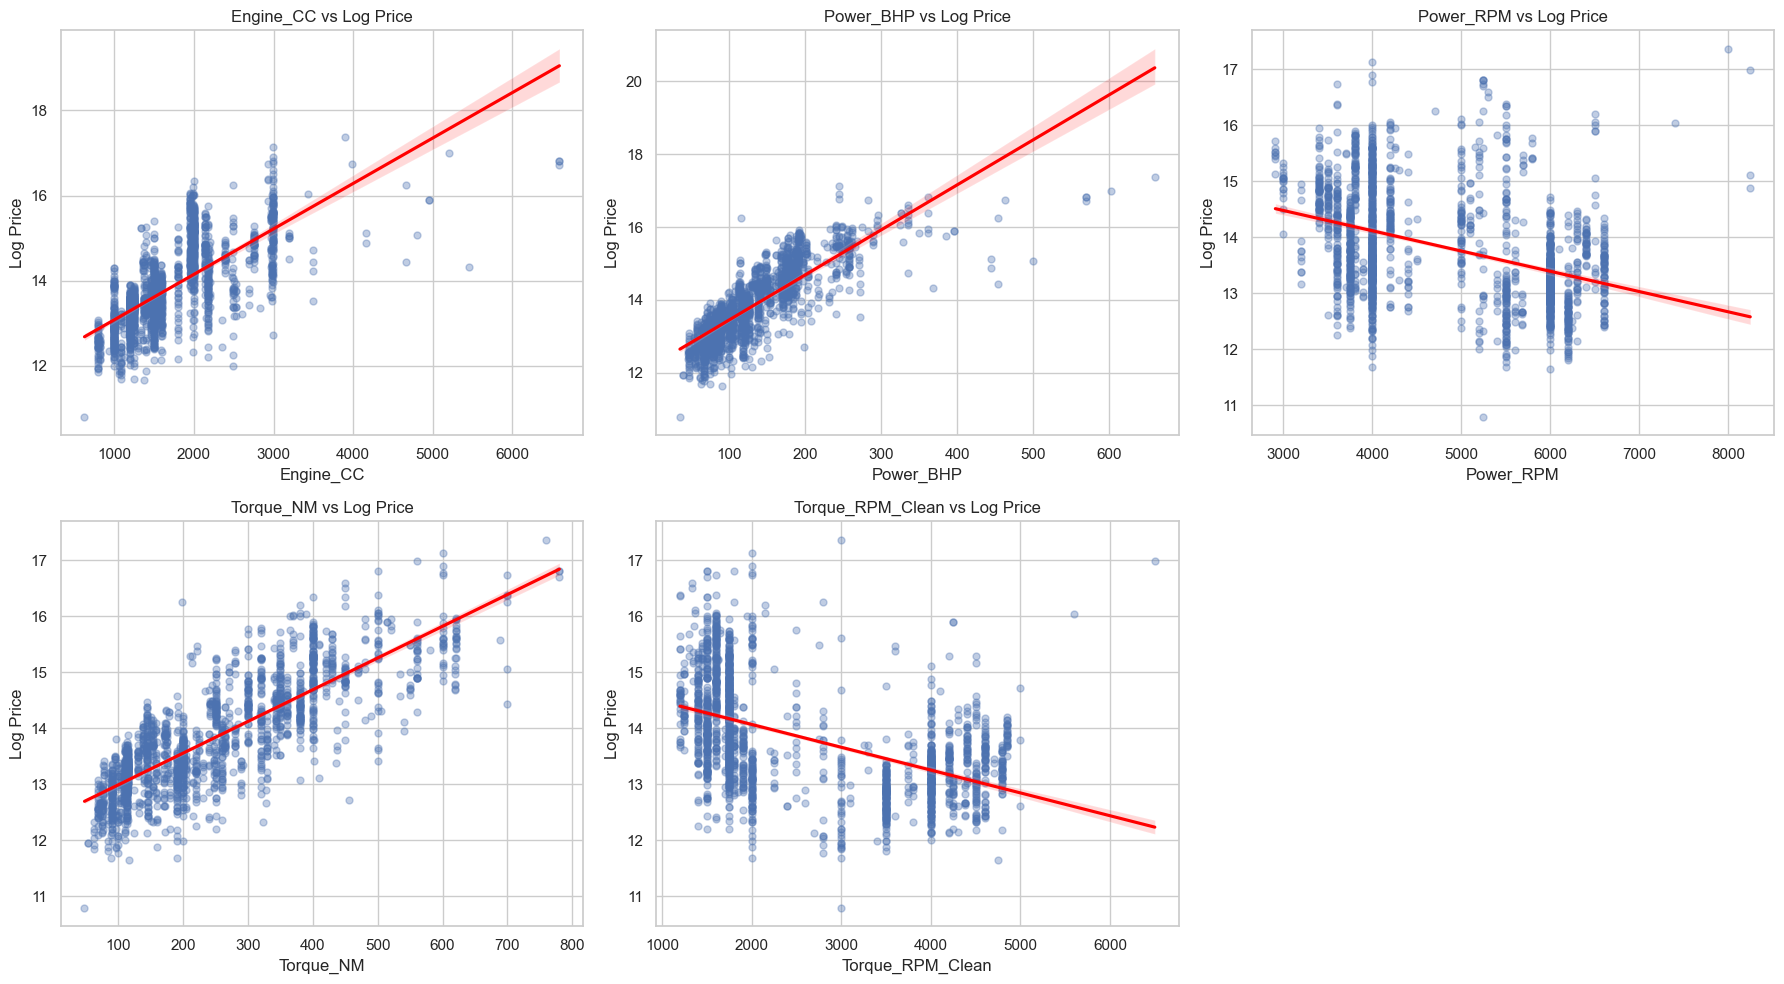

In [27]:
technical_price_features = [
    "Engine_CC",
    "Power_BHP",
    "Power_RPM",
    "Torque_NM",
    "Torque_RPM_Clean"
]

technical_correlations = (
    df[
        technical_price_features +
        ["Log Price"]
    ]
    .corr()
    ["Log Price"]
    .drop("Log Price")
    .sort_values(ascending=False)
)

print("Technical correlations with Log Price:")
print(
    technical_correlations.round(3)
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for index, column in enumerate(technical_price_features):
    sns.regplot(
        data=df,
        x=column,
        y="Log Price",
        scatter_kws={
            "alpha": 0.35,
            "s": 25
        },
        line_kws={
            "color": "red"
        },
        ax=axes[index]
    )

    axes[index].set_title(
        f"{column} vs Log Price"
    )

axes[5].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/figures/technical_features_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Technical-Price Relationship Finding

Power_BHP and Torque_NM have the strongest positive relationships with
Log Price, followed by Engine_CC.

Vehicles with larger engines, greater power, and higher torque generally have
higher prices. Power_RPM and Torque_RPM show negative associations, but these
relationships should not be interpreted causally because RPM is also related
to engine and fuel technology.

Engine_CC, Power_BHP, and Torque_NM appear strongly related to one another.
This creates a potential multicollinearity problem that will be quantified
through a correlation matrix and VIF analysis.

The strong relationships and likely multicollinearity provide a practical
reason for comparing ordinary Linear Regression with Ridge, Lasso, and
Elastic Net.

## 12. Vehicle Dimensions and Capacity Features

Length, Width, Height, Seating Capacity, and Fuel Tank Capacity are examined
for their distributions and relationships with Log Price.

Dimension correlations with Log Price:
Width                 0.775
Length                0.766
Fuel Tank Capacity    0.733
Height                0.170
Seating Capacity      0.097
Name: Log Price, dtype: float64


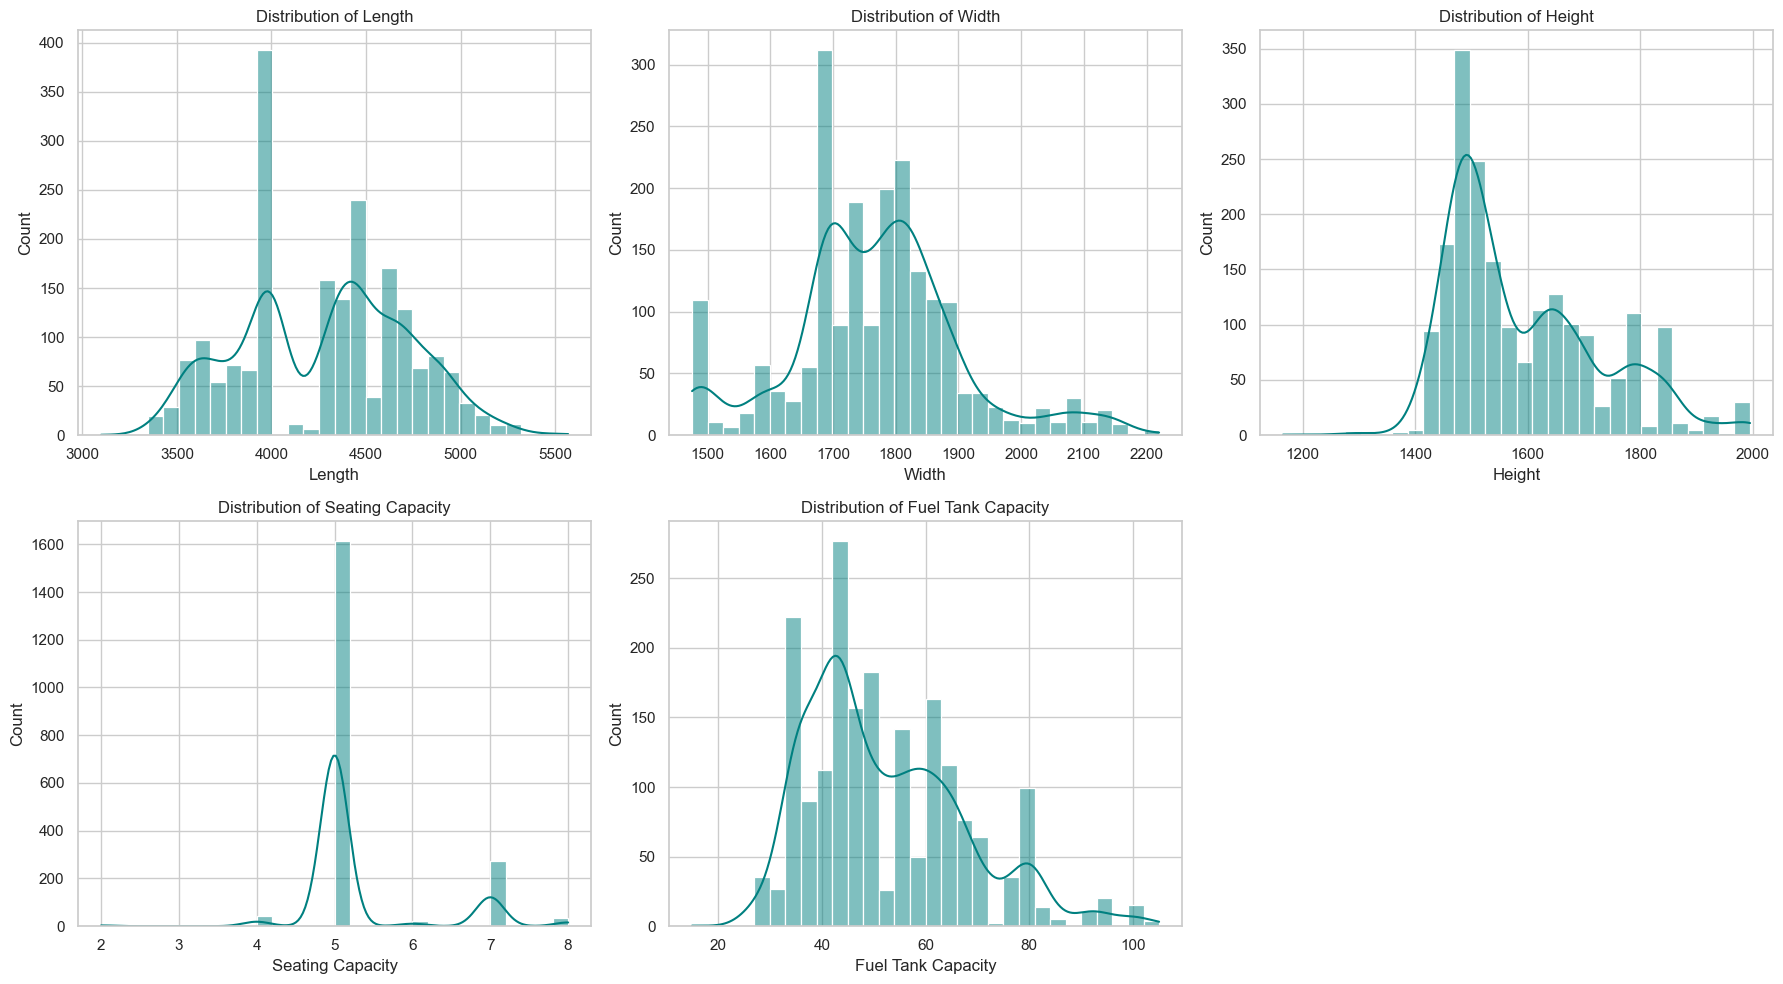

In [28]:
dimension_features = [
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity"
]

dimension_correlations = (
    df[
        dimension_features +
        ["Log Price"]
    ]
    .corr()
    ["Log Price"]
    .drop("Log Price")
    .sort_values(ascending=False)
)

print("Dimension correlations with Log Price:")
print(
    dimension_correlations.round(3)
)

fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for index, column in enumerate(dimension_features):
    sns.histplot(
        data=df,
        x=column,
        bins=30,
        kde=True,
        ax=axes[index],
        color="teal"
    )

    axes[index].set_title(
        f"Distribution of {column}"
    )

axes[5].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/figures/dimension_feature_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

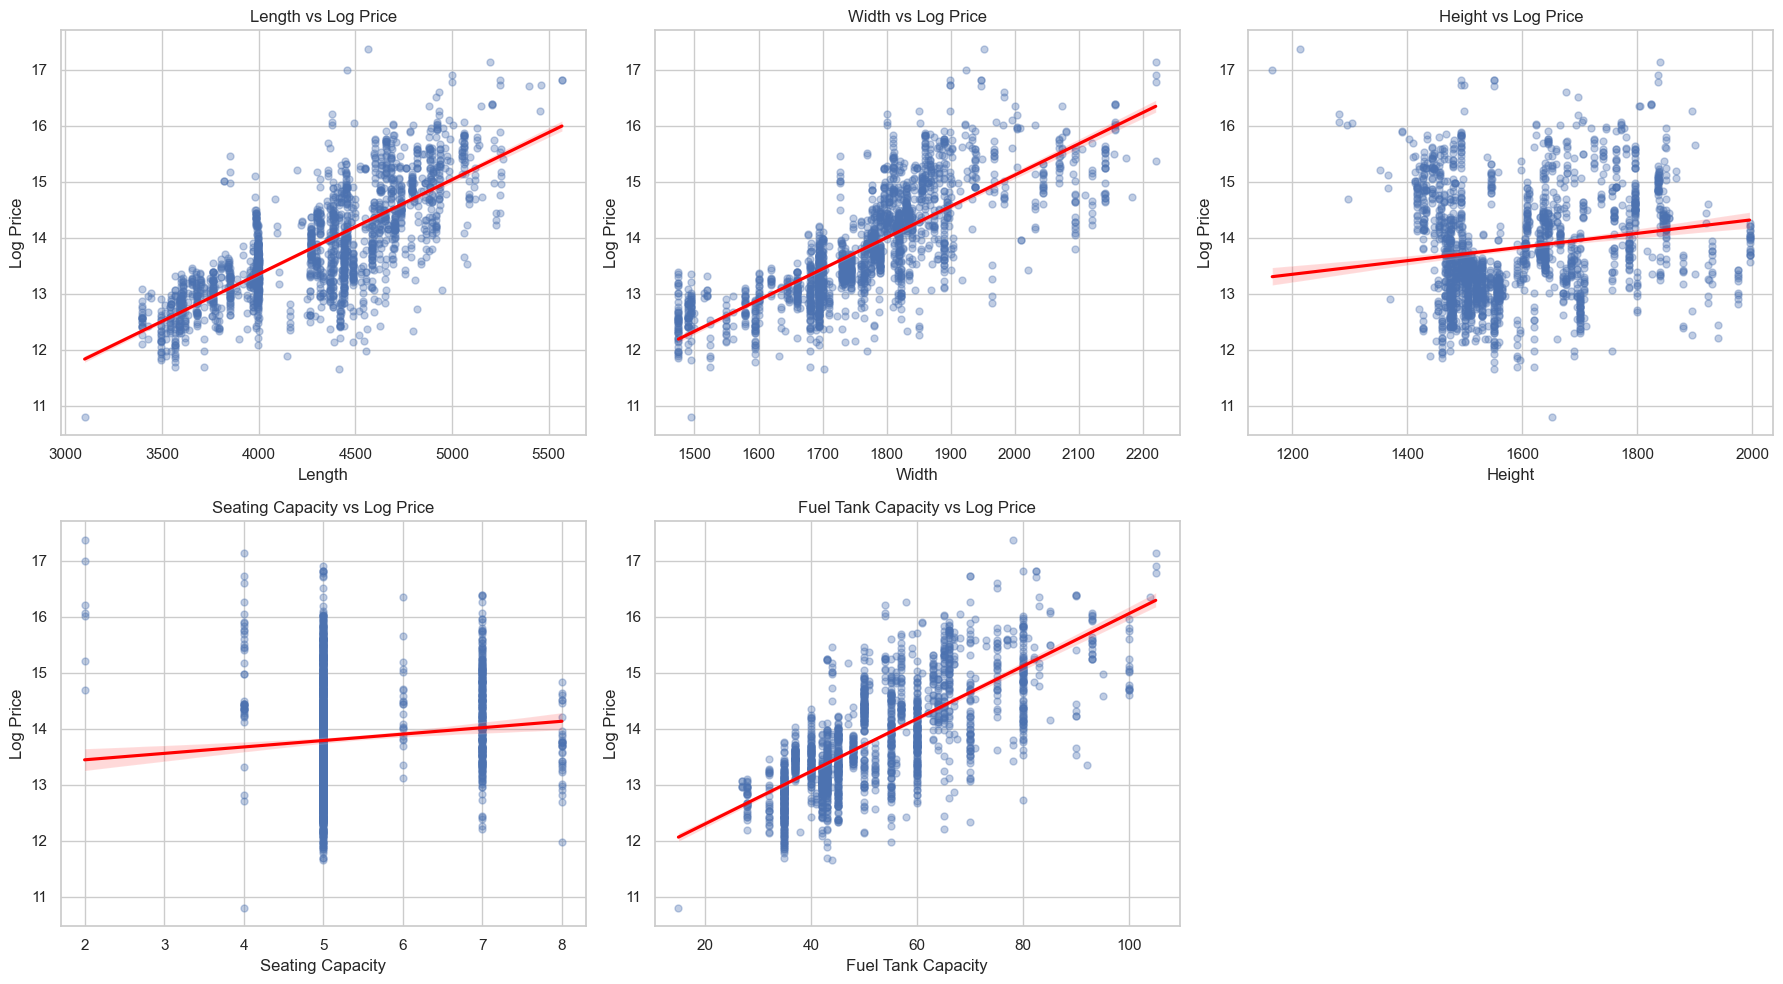

In [29]:
fig, axes = plt.subplots(
    2,
    3,
    figsize=(18, 10)
)

axes = axes.flatten()

for index, column in enumerate(dimension_features):
    sns.regplot(
        data=df,
        x=column,
        y="Log Price",
        scatter_kws={
            "alpha": 0.35,
            "s": 25
        },
        line_kws={
            "color": "red"
        },
        ax=axes[index]
    )

    axes[index].set_title(
        f"{column} vs Log Price"
    )

axes[5].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/figures/dimensions_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Dimension–Price Relationship Finding

Length, Width, and Fuel Tank Capacity show clear positive relationships with
Log Price. Larger vehicles generally belong to more expensive market segments.

Height has only a weak positive trend, while Seating Capacity shows substantial
price overlap across categories. A higher seat count does not independently
guarantee a higher vehicle price.

The repeated vertical groups represent standardized manufacturer
specifications. Dimension features may capture overlapping vehicle-size
information and will require multicollinearity analysis.

## 13. Core Categorical Features and Price

Boxplots compare the Log Price distributions across Fuel Type, Transmission,
Owner, Seller Type, and Drivetrain categories.

Category sample sizes and imbalance will be considered during interpretation.

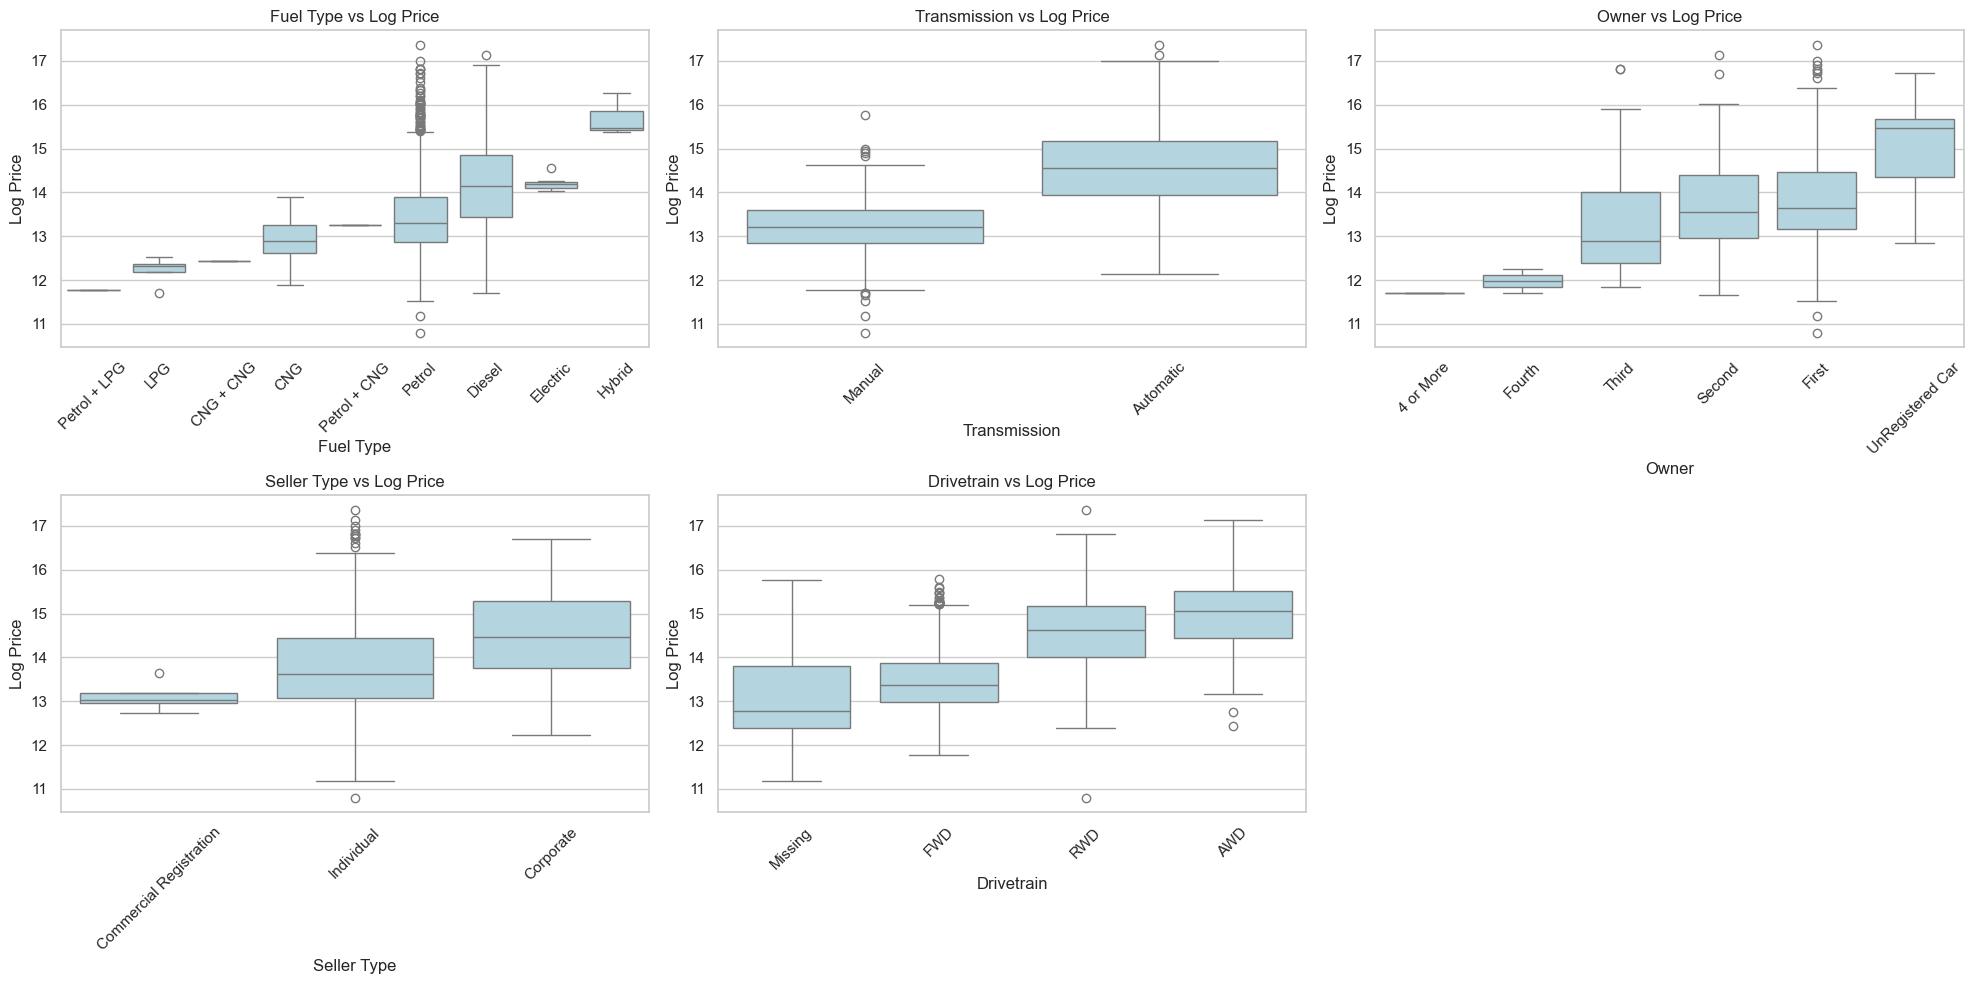

In [31]:
categorical_eda = df.copy()

categorical_price_features = [
    "Fuel Type",
    "Transmission",
    "Owner",
    "Seller Type",
    "Drivetrain"
]

for column in categorical_price_features:
    categorical_eda[column] = (
        categorical_eda[column]
        .fillna("Missing")
    )

fig, axes = plt.subplots(
    2,
    3,
    figsize=(20, 10)
)

axes = axes.flatten()

for index, column in enumerate(categorical_price_features):

    category_order = (
        categorical_eda
        .groupby(column)["Log Price"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=categorical_eda,
        x=column,
        y="Log Price",
        order=category_order,
        ax=axes[index],
        color="lightblue"
    )

    axes[index].set_title(
        f"{column} vs Log Price"
    )

    axes[index].tick_params(
        axis="x",
        rotation=45
    )

axes[5].axis("off")

plt.tight_layout()

plt.savefig(
    "../results/figures/categorical_features_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Core Categorical-Price Finding

Automatic, AWD, RWD, corporate-listed, and unregistered vehicles generally
have higher median Log Prices.

Diesel vehicles have a higher median than Petrol vehicles. Hybrid and Electric
categories appear expensive, but their sample sizes are too small for strong
generalization.

Several fuel, ownership, and seller categories contain very few observations.
Their boxplots are unstable and must be interpreted cautiously.

Missing Drivetrain records have a distinct Price distribution, suggesting
that missingness may contain information. Treating missing Drivetrain as an
explicit category may be preferable to simple mode imputation.

`CNG + CNG` will be standardized to `CNG`, while `Fourth` and `4 or More`
will be grouped as `Fourth or More`.

## 14. Make, Location, and Color Effects

The fifteen most frequent Makes and Locations are analyzed to avoid unstable
comparisons based on extremely rare categories.

All Color categories are retained for exploratory comparison.

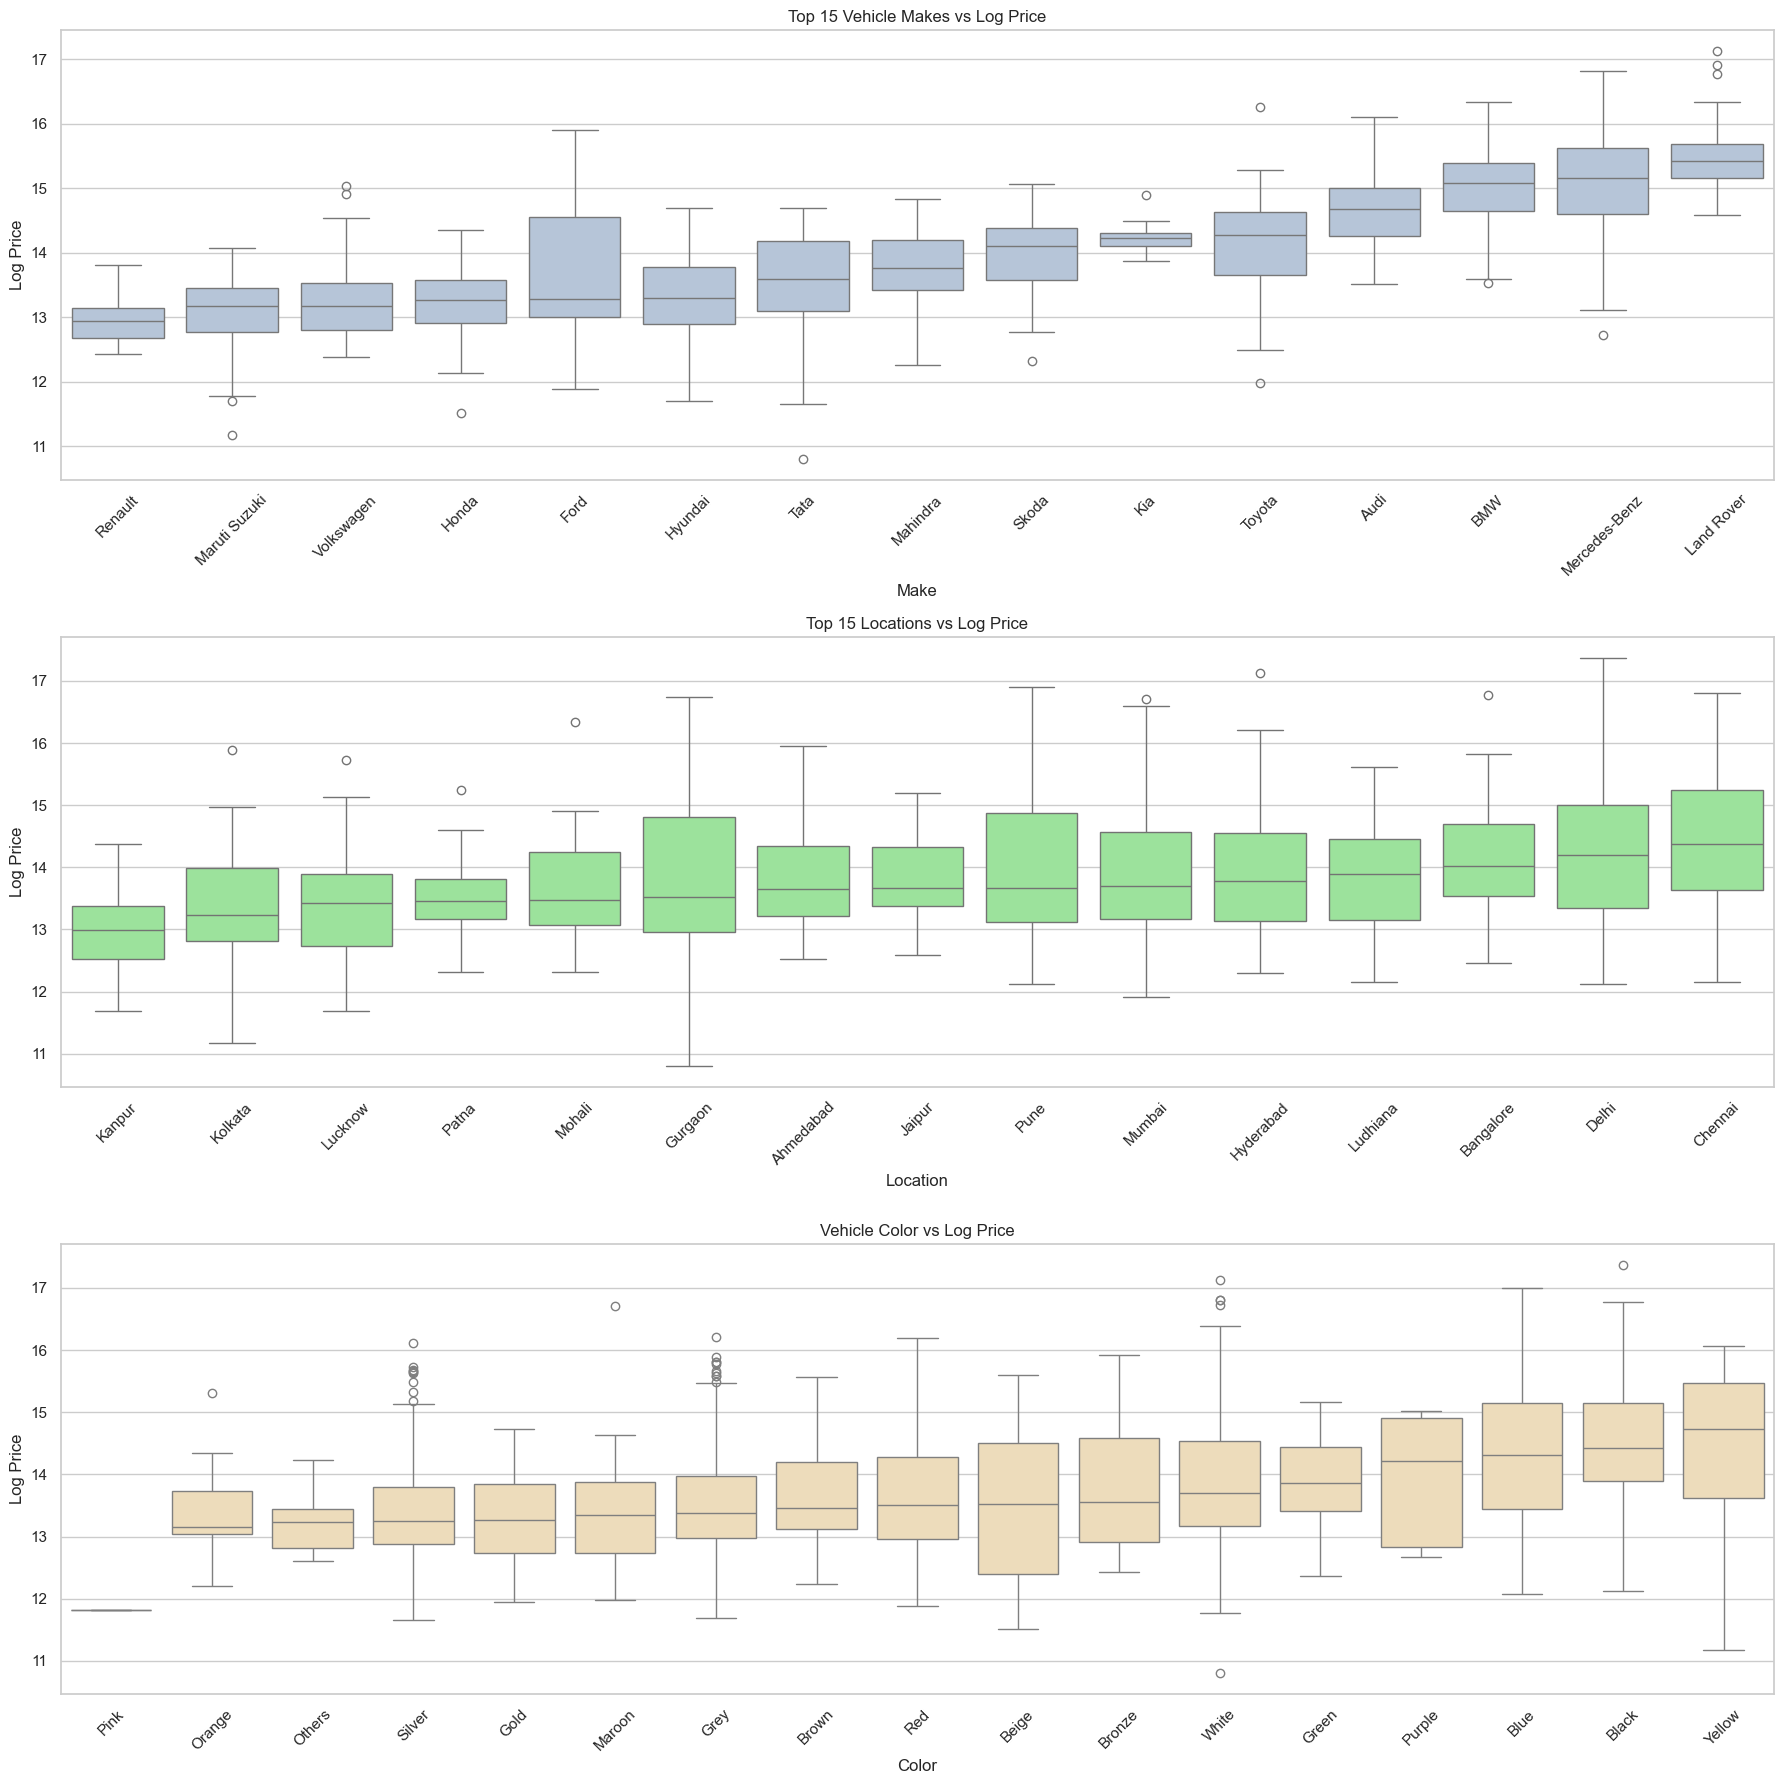

In [32]:
top_makes = (
    df["Make"]
    .value_counts()
    .head(15)
    .index
)

top_locations = (
    df["Location"]
    .value_counts()
    .head(15)
    .index
)

make_data = df[
    df["Make"].isin(top_makes)
]

location_data = df[
    df["Location"].isin(top_locations)
]

make_order = (
    make_data
    .groupby("Make")["Log Price"]
    .median()
    .sort_values()
    .index
)

location_order = (
    location_data
    .groupby("Location")["Log Price"]
    .median()
    .sort_values()
    .index
)

color_order = (
    df
    .groupby("Color")["Log Price"]
    .median()
    .sort_values()
    .index
)

fig, axes = plt.subplots(
    3,
    1,
    figsize=(18, 18)
)

sns.boxplot(
    data=make_data,
    x="Make",
    y="Log Price",
    order=make_order,
    ax=axes[0],
    color="lightsteelblue"
)

axes[0].set_title(
    "Top 15 Vehicle Makes vs Log Price"
)
axes[0].tick_params(
    axis="x",
    rotation=45
)

sns.boxplot(
    data=location_data,
    x="Location",
    y="Log Price",
    order=location_order,
    ax=axes[1],
    color="lightgreen"
)

axes[1].set_title(
    "Top 15 Locations vs Log Price"
)
axes[1].tick_params(
    axis="x",
    rotation=45
)

sns.boxplot(
    data=df,
    x="Color",
    y="Log Price",
    order=color_order,
    ax=axes[2],
    color="wheat"
)

axes[2].set_title(
    "Vehicle Color vs Log Price"
)
axes[2].tick_params(
    axis="x",
    rotation=45
)

plt.tight_layout()

plt.savefig(
    "../results/figures/make_location_color_vs_log_price.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Make, Location, and Color Finding

Vehicle Make produces clear Price separation between mass-market and premium
brands, making it an important categorical predictor.

Location medians differ, but their distributions overlap substantially.
Location effects may partly reflect differences in the brands and vehicle
segments listed in each city rather than an independent causal effect.

Color also shows median differences, but several colors contain very few
observations. Rare-color effects are unstable and may reflect association
with premium brands rather than a direct effect on Price.

Rare Location and Color categories will be grouped or controlled through the
encoding strategy.

## 15. High-Cardinality Model Analysis

Model has many unique values relative to the dataset size. Its frequency
structure is examined before selecting an encoding strategy.

In [33]:
model_counts = df["Model"].value_counts()

print("Total observations:", len(df))
print("Unique Models:", df["Model"].nunique())

print(
    "Models appearing once:",
    (model_counts == 1).sum()
)

print(
    "Models appearing two times or fewer:",
    (model_counts <= 2).sum()
)

print(
    "Models appearing five times or more:",
    (model_counts >= 5).sum()
)

print(
    "Maximum records for one Model:",
    model_counts.max()
)

print("\nTop 15 most frequent Models:")
print(model_counts.head(15))

Total observations: 2059
Unique Models: 1050
Models appearing once: 613
Models appearing two times or fewer: 828
Models appearing five times or more: 72
Maximum records for one Model: 15

Top 15 most frequent Models:
Model
X1 sDrive20d xLine                       15
Swift DZire VDI                          14
City V                                   13
Fortuner 2.8 4x2 AT [2016-2020]          13
Swift DZire VXI                          12
Swift VXi [2014-2017]                    12
Swift VXi                                12
5-Series 520d Luxury Line [2017-2019]    10
A6 35 TDI Matrix                         10
Verna Fluidic 1.6 CRDi SX                10
Alto VXi                                  9
GLE 250 d                                 9
Alto 800 Lxi                              9
Swift VDi                                 9
City 1.5 S MT                             9
Name: count, dtype: int64


### Model Cardinality Interpretation

`Model` is a high-cardinality categorical feature. The dataset contains
1,050 unique model names among only 2,059 observations.

A total of 613 models occur once, while 828 models occur no more than twice.
Only 72 models have at least five observations, and the most frequent model
appears only 15 times.

Direct one-hot encoding of every model name may create a large and highly
sparse feature matrix. Rare model categories may also encourage overfitting
because their estimated effects would be based on very few observations.

However, vehicle model can contain important pricing information, so it will
not be discarded without evaluation. Two modeling strategies will be compared:

1. A baseline model that excludes `Model`.
2. A model that uses frequency-controlled one-hot encoding, where categories
   occurring fewer than five times are grouped as infrequent categories.

The preprocessing and evaluation procedures must be fitted on training data
only to prevent data leakage.

## 16. Missing-Value Pattern Analysis

In [34]:
missing_columns = [
    "Engine",
    "Max Power",
    "Max Torque",
    "Drivetrain",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity"
]

missing_summary = pd.DataFrame({
    "Missing Count": df[missing_columns].isnull().sum(),
    "Missing Percent": (
        df[missing_columns].isnull().mean() * 100
    ).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

missing_summary

,Missing Count,Missing Percent
Drivetrain,136,6.61
Fuel Tank Capacity,113,5.49
Engine,80,3.89
Max Power,80,3.89
Max Torque,80,3.89
Length,64,3.11
Width,64,3.11
Height,64,3.11
Seating Capacity,64,3.11


### Missing-Value Summary

The percentage of missing values ranges from 3.11% to 6.61%, which is
manageable and does not justify removing complete columns.

Engine, power, and torque variables have identical missing counts. Similarly,
the main vehicle-dimension variables share the same missing counts. This
suggests that some values may be missing together because complete technical
specifications were unavailable for particular vehicles.

Individual missing percentages cannot determine whether missing values occur
independently or in groups. Therefore, missing-value combinations are examined
before deciding the final imputation strategy.

No rows or columns are removed during EDA. Imputation will later be performed
inside the preprocessing pipeline using training data only.

In [35]:
missing_pattern_counts = (
    df[missing_columns]
    .isnull()
    .astype(int)
    .value_counts()
    .reset_index(name="Number of Rows")
)

print("0 = value is present")
print("1 = value is missing")

missing_pattern_counts.head(10)

0 = value is present
1 = value is missing


,Engine,Max Power,Max Torque,Drivetrain,Length,Width,Height,Seating Capacity,Fuel Tank Capacity,Number of Rows
0,0,0,0,0,0,0,0,0,0,1874
1,1,1,1,1,1,1,1,1,1,64
2,0,0,0,1,0,0,0,0,0,63
3,0,0,0,0,0,0,0,0,1,42
4,1,1,1,1,0,0,0,0,0,9
5,1,1,1,0,0,0,0,0,1,7


### Missing-Pattern Interpretation

A total of 1,874 observations, approximately 91% of the dataset, contain
complete values for all examined specification variables.

The missing values show clear co-occurrence patterns:

- 64 observations have all nine specification variables missing.
- 63 observations have only `Drivetrain` missing.
- 42 observations have only `Fuel Tank Capacity` missing.
- 16 additional observations have Engine, Power, and Torque information
  missing together with either Drivetrain or Fuel Tank Capacity.

These results show that the missing values are structured rather than
independently scattered across columns. For example, engine, power, and torque
specifications tend to be unavailable as a group.

However, this pattern alone cannot establish whether the statistical missingness
mechanism is MCAR, MAR, or MNAR.

Rows containing missing values will not be removed during EDA. During modeling,
numerical variables will be imputed using training-set medians. Missing
categorical values such as Drivetrain will be represented by an explicit
`Missing` category. Missing-value indicators may also be evaluated because the
absence of specifications can itself contain predictive information.

## 17. Numerical Correlation and Multicollinearity Screening

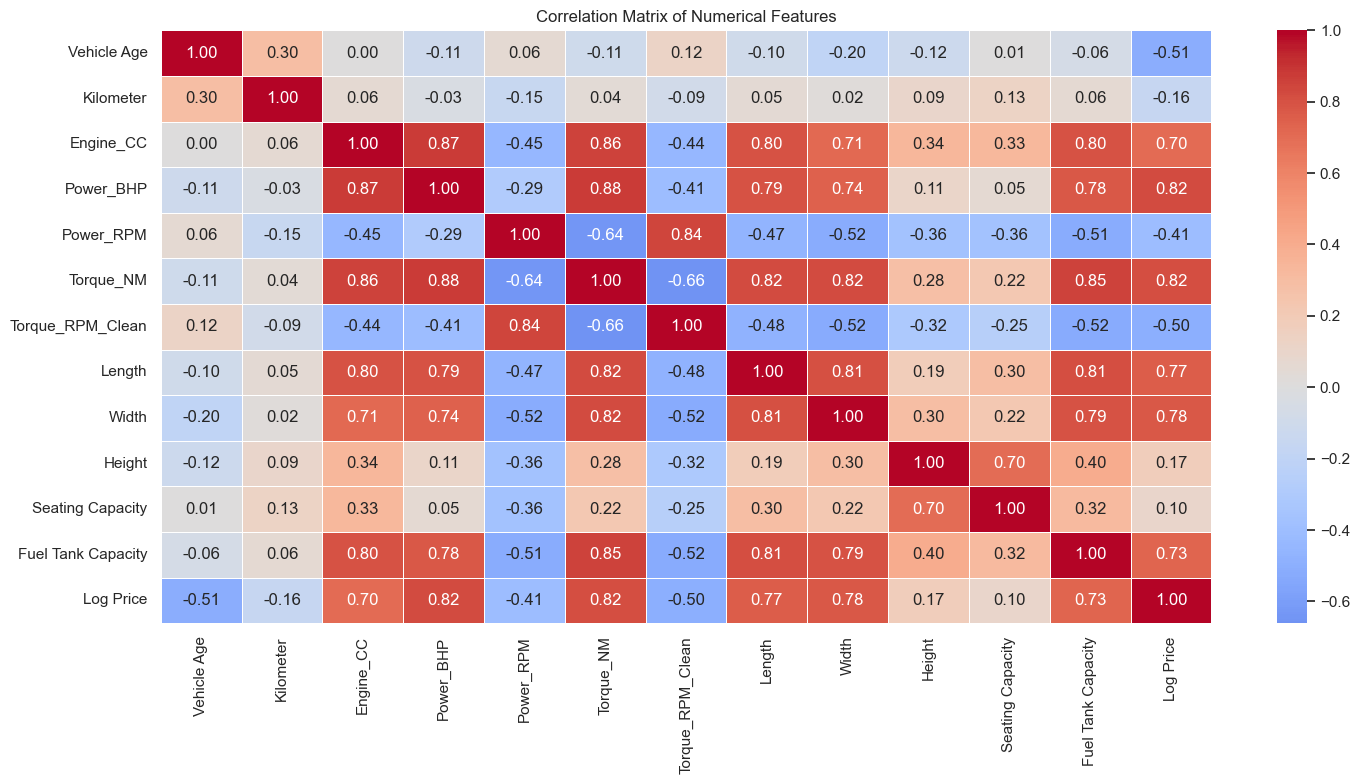

In [38]:
numerical_eda_columns = [
    "Vehicle Age",
    "Kilometer",
    "Engine_CC",
    "Power_BHP",
    "Power_RPM",
    "Torque_NM",
    "Torque_RPM_Clean",
    "Length",
    "Width",
    "Height",
    "Seating Capacity",
    "Fuel Tank Capacity",
    "Log Price"
]

numerical_correlation = (
    df[numerical_eda_columns]
    .corr(method="pearson")
)

plt.figure(figsize=(15, 8))

sns.heatmap(
    numerical_correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()

plt.savefig(
    "../results/figures/numerical_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlation and Multicollinearity Interpretation

The correlation matrix identifies vehicle performance and size variables as
the strongest numerical predictors of log-transformed price.

`Power_BHP` and `Torque_NM` both have correlations of approximately 0.82 with
Log Price. Width, Length, Fuel Tank Capacity, and Engine_CC also show strong
positive relationships with Log Price.

Vehicle Age has a moderate negative correlation of -0.51, indicating that older
vehicles generally have lower prices. Kilometer has a weaker Pearson
correlation of -0.16 because its relationship is influenced by an extreme
two-million-kilometer observation. Earlier robust and percentile-based analyses
showed a clearer negative association.

Several predictors are also strongly correlated with each other. Engine_CC,
Power_BHP, and Torque_NM have pairwise correlations between 0.86 and 0.88.
Length, Width, Fuel Tank Capacity, and technical performance variables also
show strong positive correlations.

These relationships indicate substantial multicollinearity. A larger engine
usually accompanies greater power, torque, vehicle dimensions, and fuel
capacity. Therefore, the variables represent overlapping aspects of vehicle
size and market segment.

Multicollinearity may make Ordinary Least Squares coefficients unstable and
difficult to interpret. This provides a clear justification for comparing
Linear Regression with Ridge, Lasso, and Elastic Net regularization.

Negative correlations involving Power_RPM and Torque_RPM should not be
interpreted causally. They may reflect differences between vehicle segments,
engine technologies, and fuel types.

Correlation describes association and does not establish that a feature causes
a change in vehicle price. Exact multicollinearity diagnostics, including VIF,
will be calculated after preprocessing in the modeling stage.

# 18. Final EDA Findings

The exploratory data analysis produced the following main findings:

### Dataset Quality

The dataset contains 2,059 used-vehicle observations and 20 original variables.
No exact duplicate rows were identified. Missing values are moderate, with no
column exceeding 6.61% missingness.

Missing values are structured. Engine, power, and torque specifications are
often unavailable together, while some observations lack complete technical
and dimensional information. These rows will be retained and handled through
pipeline-based imputation.

### Target Variable

Vehicle Price is strongly right-skewed, with a skewness value of 4.97. A small
number of luxury vehicles have substantially higher prices than the majority
of observations.

The log transformation reduced Price skewness to 0.49. Therefore, models using
both original Price and log-transformed Price will be compared. Valid luxury
vehicle records will not be removed merely because they have high prices.

### Vehicle Age and Kilometer

Vehicle Age has a moderate negative relationship with price. Its Pearson
correlation with Log Price is -0.51, indicating that older vehicles generally
have lower market values.

Kilometer contains a two-million-kilometer high-leverage observation. The
complete-data Pearson correlation with Log Price is -0.16, while percentile-
restricted and rank-based analyses show a clearer negative association.

Extreme kilometer values will not be removed silently. Their effect will be
evaluated through sensitivity analysis and cross-validation.

### Technical Specifications

Engine, power, and torque information was converted from text into numerical
features:

- Engine_CC
- Power_BHP
- Power_RPM
- Torque_NM
- Torque_RPM

Four Power_RPM values remain missing because the original strings did not
contain RPM values. One suspicious Torque_RPM value of 150 RPM was detected
and converted to missing in the derived `Torque_RPM_Clean` feature without
modifying the raw data.

Power_BHP, Torque_NM, and Engine_CC show strong positive relationships with Log
Price. These variables are important predictors but are also strongly related
to one another.

### Vehicle Dimensions

Width, Length, and Fuel Tank Capacity have strong positive associations with
Log Price. Height and Seating Capacity show weaker individual relationships.

These variables reflect vehicle size and market segment and may contain
information that overlaps with engine, power, and torque specifications.

### Categorical Features

Transmission, Fuel Type, Drivetrain, Owner, Seller Type, Make, Location, and
Color show differences in their price distributions.

Automatic, AWD, RWD, premium-brand, and unregistered vehicles generally have
higher median prices. However, some categories contain very few observations,
so their apparent effects may be unstable.

These relationships are observational and may be influenced by vehicle brand,
model, age, technical specifications, and market segment. They should not be
interpreted as causal effects.

### High-Cardinality Features

`Model` is a high-cardinality feature with 1,050 unique categories. A total of
613 models appear once, while only 72 models occur at least five times.

Directly encoding every model may create a sparse feature matrix and encourage
overfitting. Modeling experiments will compare excluding Model with controlled
one-hot encoding that groups infrequent categories.

### Multicollinearity

Strong correlations exist among Engine_CC, Power_BHP, Torque_NM, Length, Width,
and Fuel Tank Capacity.

This multicollinearity may produce unstable Ordinary Least Squares
coefficients. It provides a practical and research-based justification for
comparing Linear Regression with Ridge, Lasso, and Elastic Net regression.

### Overall Assessment

The dataset is suitable for educational modeling, portfolio development, and
methodological comparison of linear and regularized regression algorithms.

However, the results should represent associations within this dataset and
should not be presented as causal conclusions or as a complete representation
of the entire used-car market.